In [1]:
from gc import DEBUG_LEAK

import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as scp
import uproot
import matplotlib
#from astropy.io.misc.asdf.tags.fits.fits import FitsType
from numba.cuda.libdevice import cbrtf
from pyvista.examples.cells import Pixel
from simpleparse.stt.TextTools import alpha
from sympy import false

font = {'weight' : 'bold',
        'size'   : 15}

matplotlib.rc('font', **font)
### Opticks Nexus Analysis

import h5py
from pandas import read_hdf
import seaborn as sns
import scipy.special as misc
from scipy.special import loggamma

isSafeFiles=False
SavePath="/home/argon/Projects/Ilker/CRAB_Diffusion/OpticksPaperImages/Needle"

In [2]:
import scipy.special as misc
from scipy.special import loggamma

def factorial(x):
    return np.math.factorial(np.uint64(x))

def Gauss1D(x,Ampl,mean,sigma):
    return Ampl*np.exp(-(x-mean)**2/(2*(sigma)**2)) 

def Gauss1DSkew(x,Ampl,mean,sigma,a,offset):
    return Ampl*np.exp(-(x-mean)**2/(2*(sigma+a*(x-mean))**2))+offset

def Poisson1D(x,gamma):
    #vfactorial=np.vectorize(factorial)
    return (gamma**x)*np.exp(-gamma)/(misc.factorial(x))

## https://stackoverflow.com/questions/53308919/overflow-error-in-poisson-distribution-implementation
## Solves overflow issue
def log_Likelihood(x,gamma):
    return (np.log(gamma)*x - loggamma(x+1)-gamma)
    #return (np.log(gamma)*x - np.log(1/(misc.factorial(x)))-gamma)

def exp(x,A1,t1,A2,t2):
    return A1*np.exp(-x/t1)+A2*np.exp(-x/t2)

In [3]:
wavelength=lambda E:1239.8/E # ev to nm 
GetEnergy=lambda w:1239.8/w # ev to nm 

def ListofFiles(path,extension="h5"):
    filelist=[]
    for root, dirs, files in os.walk(path):
        for file in files:
            if file.endswith(extension):
                filelist.append(os.path.join(root,file))
    return filelist
def GetInfo(filePath,FileLimit=-1,isCombined=True,EventLimit=-1,SkipKeys=None,SkipSubKeys=None):
    All={}
    subVal={}
    subsubVal={}
    if(filePath.endswith("h5")):
        f=h5py.File(filePath,"r")
        
        for folder in f:
            subVal={}
            for table in f[folder]:
                subsubVal={}
                if(SkipKeys!=None and table in SkipKeys ):
                    continue
                    
                for field in f[folder][table].dtype.fields.keys():
                    if(field in SkipSubKeys):
                        continue 
                    subsubVal[field]=f[folder][table][field]
                if(subsubVal):    
                    subVal[table]=subsubVal
            All[folder]=subVal
        f.close()
    else:
        Files=ListofFiles(filePath)
        Counter=0
        Combined={}
        SingleFile={}
        for file in Files:
            f=h5py.File(file,"r")
            print(file)
            if(not isCombined):
                SingleFile={}
            for folder in f:
                subVal={}
                for table in f[folder]:
                    subsubVal={}
                    if(SkipKeys!=None and table in SkipKeys ):
                        continue
                    for field in f[folder][table].dtype.fields.keys():
                        #if no value then ignore it
                        
                        if(field in SkipSubKeys):
                            continue
                        subsubVal[field]=np.array(f[folder][table][field])
    
                        if(subsubVal[field].size == 0):
                            continue
                        if(Combined):
                            MaxEventID=0
                            if(field=="event_id" and Counter>0):
                                #print(f"{table}/{field}")
                                MaxEventID=np.max(Combined[table][field])+1
                                #print(Combined[table][field])
                                subsubVal[field]=MaxEventID+subsubVal[field]
                                #print(MaxEventID)
                                #print(subsubVal[field])
                            Combined[table][field]=np.hstack((Combined[table][field],subsubVal[field]))
                    if(subsubVal):        
                        subVal[table]=subsubVal
                if(not isCombined and (subVal)):    
                    SingleFile[folder]=subVal
                else:
                    if(Counter==0 and (subVal)):
                        print("Setting Combined Value")
                        Combined=subVal
            f.close()
            if(not isCombined):
                All[Counter]=SingleFile
            if(FileLimit==Counter):
                break   
            Counter+=1
        if(isCombined):
            All=Combined
    return All

In [60]:
#vv=GetInfo("/home/argon/Projects/Ilker/NewNexus/test_.h5")
import os
vv=GetInfo("/home/argon/Projects/Ilker/NewNexus/test0SkipHead.h5",SkipKeys=[],SkipSubKeys=[])
#vv=GetInfo("/home/argon/Projects/Ilker/NewNexus/output/Opticks_Hit_Comparison/Comsol.h5")

In [61]:
print(vv)

{'MC': {'GEANT4_Optical_Hits': {'event_id': array([   0,    0,    0, ..., 1999, 1999, 1999]), 'name': array([b'PMTWindow', b'PMTWindow', b'PMTWindow', ..., b'camWindow',
       b'PMTWindow', b'camWindow'], dtype='|S100'), 'hit_id': array([  0,   1,   2, ..., 209, 210, 211], dtype=int32), 'x': array([ 4.1852536 ,  5.899659  , -5.132583  , ...,  1.0373133 ,
       -7.340351  ,  0.93133646], dtype=float32), 'y': array([ 3.5586066 ,  4.5544405 , -8.70145   , ...,  0.03632293,
        1.4983251 ,  0.7557199 ], dtype=float32), 'z': array([-248.85, -248.85, -248.85, ...,  302.15, -248.85,  302.15],
      dtype=float32), 'time': array([116.5195  , 106.57857 ,  97.4698  , ..., 460.70422 ,  20.396437,
        30.920597], dtype=float32), 'wavelength': array([178.07399, 168.26439, 178.33215, ..., 162.01749, 171.62408,
       178.17157], dtype=float32), 'polx': array([-0.91186863, -0.7288867 , -0.62070745, ..., -0.5802446 ,
        0.8678186 ,  0.09478223], dtype=float32), 'poly': array([ 0.3885572

In [62]:
MC={}
if("DEBUG" in vv):
    DEBUG=vv["DEBUG"]
if("MC" in vv):    
    MC=vv["MC"]
else:
    MC=vv
    

In [63]:
def FitHist1D(hist,ax,label,clr,ap):
    ## Locate Min and Max
    MinAndMaxMask=(hist[0]>=(np.mean(hist[0])*0.1)) & (hist[0]<=np.max(hist[0])*0.9)
    
    initials=(np.max(hist[0]),np.mean(hist[1][:-1][MinAndMaxMask]),np.std(hist[1][:-1][MinAndMaxMask]),0,0)
    #initials=(np.max(hist[0]),0,np.std(hist[1][:-1][MinAndMaxMask]),0,0)
    print(f"Initials {initials}")
    fit=scp.curve_fit(Gauss1DSkew,hist[1][:-1],hist[0],p0=initials,maxfev=5000)
    String_=label+r', $\bar{X}$'+f"={round(fit[0][1],2)}," + r'$\sigma$' +f"= {abs(round(fit[0][2],2))}"
    #ax.text(np.min(data),fit[0][0],s=String_,color=clr)
    if(ax):
        ax.plot(hist[1][:-1],Gauss1DSkew(hist[1][:-1],*fit[0]),label=String_,color=clr,alpha=ap,linewidth=3)
    FitValues={"Amp":round(fit[0][0],2),"u":round(fit[0][1],2),"sigma":abs(round(fit[0][2],2)),"offset":round(fit[0][3],2)}
    print(FitValues)
    return FitValues
    

def FitExp(hist,ax,label,clr,ap,fitType=["Hist",0]):
    try:
        if(fitType[0]=="Hist"):
            initials=(np.max(hist[0]),4.5,np.max(hist[0])/2,100)
            fit=scp.curve_fit(exp,hist[1][:-1],hist[0],p0=initials)
            String_=label+f",t1={abs(round(fit[0][1],2))},t2={abs(round(fit[0][3],2))}"
            #ax.text(np.min(data),fit[0][0],s=String_,color=clr)
            ax.plot(hist[1][:-1],exp(hist[1][:-1],*fit[0]),label=String_,color=clr,alpha=ap,linewidth=3)
        else:
            initials=(np.max(hist),4.5,np.max(hist)/2,100)
            x=np.sort(hist)
            y=exp(x,*initials)
            fit=scp.curve_fit(exp,x,y,p0=initials)
            String_=label+f",t1={abs(round(fit[0][1],2))},t2={abs(round(fit[0][3],2))}"
            #ax.text(np.min(data),fit[0][0],s=String_,color=clr)
            
            ax.plot(x,exp(x,fit[0][0]*fitType[1],fit[0][1],fit[0][2]*fitType[1],fit[0][3]),label=String_,color=clr,alpha=ap,linewidth=3)
    except(RuntimeError):
        print("There was an error in fitting ")
    

In [64]:
if("DEBUG" in vv):
    Opticks=DEBUG['opticks_photon_info']
G4=MC["particles"]
G4Hits=MC["GEANT4_Optical_Hits"]

OpticksHits=MC['Opticks_Hits']
Mask=G4["particle_name"]==b'opticalphoton'

In [65]:
print(OpticksHits)
print(G4Hits)

{'event_id': array([   0,    0,    0, ..., 1999, 1999, 1999]), 'hit_id': array([    41,   1670,   1797, ..., 135459, 135721, 137378], dtype=int32), 'x': array([ 0.33887765, -5.0411825 ,  7.8342705 , ...,  1.1213324 ,
       -2.8351471 , 10.708299  ], dtype=float32), 'y': array([ 8.001471  , -7.591466  , -2.2186854 , ...,  0.35818905,
        4.9597425 , -1.096401  ], dtype=float32), 'z': array([-248.85, -248.85, -248.85, ...,  302.15, -248.85,  302.15],
      dtype=float32), 'time': array([ 2.5598166, 27.079075 , 92.680626 , ..., 51.12413  , 32.222485 ,
       83.53997  ], dtype=float32), 'wavelength': array([175.4798 , 176.31284, 174.9794 , ..., 176.38663, 178.69687,
       177.6069 ], dtype=float32), 'boundary': array([31, 31, 31, ..., 29, 31, 29], dtype=uint32), 'polx': array([ 0.7474791 ,  0.4426887 , -0.94486874, ...,  0.96372205,
       -0.8800702 , -0.2190347 ], dtype=float32), 'poly': array([-0.634854  ,  0.8414799 ,  0.3257838 , ..., -0.26686168,
       -0.4747526 , -0.9740270

In [66]:
#WavelengthsOpticks=np.concatenate((Opticks["wavelength"],OpticksHits["wavelength"]))
#WavelengthsG4=np.concatenate((wavelength(G4["kin_energy"][Mask]*1e6),G4Hits["wavelength"]))
#wMax=np.max(np.array([np.max(WavelengthsG4),np.max(WavelengthsOpticks)]))
#wMin=np.min(np.array([np.min(WavelengthsG4),np.min(WavelengthsOpticks)]))
if("DEBUG" in vv):
    wMax=np.max(np.array([np.max(wavelength(G4["kin_energy"][Mask]*1e6)),np.max(Opticks["wavelength"])]))
    wMin=np.min(np.array([np.min(wavelength(G4["kin_energy"][Mask]*1e6)),np.min(Opticks["wavelength"])]))
    
    
    
    bins_=np.linspace(wMin,wMax,150)
    
    plt.figure(figsize=(10,10),dpi=300)
    plt.title("Wavelength Comparison")
    
    h1=plt.hist(Opticks["wavelength"],bins=bins_,alpha=0.3,label="Opticks",color="red",histtype="step",fill=True)
    #h1=plt.hist(WavelengthsOpticks,bins=bins_,alpha=1,label="Opticks",color="red",alpha=0.3,histtype="step",fill=True)
    FitHist1D(h1,plt,"Fit","red",0.3)
    
    
    h2=plt.hist(wavelength(G4["kin_energy"][Mask]*1e6),bins=bins_,alpha=0.3,label="G4",histtype="step",color="green",fill=True)
    #h2=plt.hist(WavelengthsG4,bins=bins_,alpha=0.5,label="G4",histtype="step",color="green",alpha=0.4,fill=True)
    FitHist1D(h2,plt,"Fit","green",0.3)
    plt.ticklabel_format(axis='y',style='sci',scilimits=(0,0),useMathText=True)
    plt.xlabel("wavelength (nm)")
    plt.legend()
    if(isSafeFiles):
        plt.savefig(f"{SavePath}/S1_Wavelength.png")
    del h1,h2

In [67]:
if("DEBUG" in vv):
    Mask=G4["particle_name"]==b'opticalphoton'
    OpticksPhotonTime=Opticks["time"]
    G4PhotonTimeInitial=G4["initial_t"][Mask]
    G4PhotonTimeFinal=G4["final_t"][Mask]

In [68]:
if("DEBUG" in vv):
    wMax=np.max(np.array([np.max(G4PhotonTimeFinal),np.max(OpticksPhotonTime)]))
    wMin=np.min(np.array([np.min(G4PhotonTimeFinal),np.min(OpticksPhotonTime)]))
    bins_=np.linspace(wMin,wMax,200)
    
    plt.figure(figsize=(8,8),dpi=300)
    plt.title("S1 Photons")
    #plt.hist(timeDifference,bins=bins_,label="G4")
    h1=plt.hist(OpticksPhotonTime,bins=bins_,label="Opticks",alpha=0.3,color="red",histtype="step",fill=True)
    FitExp(h1,plt,"Fit","red",0.3)
    h2=plt.hist(G4PhotonTimeFinal,bins=bins_,label="G4",alpha=0.3,color="green",histtype="step",fill=True)
    FitExp(h2,plt,"Fit","Green",0.3)
    #_=plt.hist(G4PhotonTimeInitial,bins=200,alpha=0.5,label="final",hatch="//")
    plt.legend()
    plt.xlabel("time(ns)")
    print(f"max {wMax} and min {wMin}")
    if(isSafeFiles):
        plt.savefig(f"{SavePath}/S1_Timing_Initial.png")
    del h1,h2

Initials (28945.0, 172.63564771503547, 8.041804797471636, 0, 0)
{'Amp': 17818.21, 'u': 172.31, 'sigma': 5.25, 'offset': 0.01}
Initials (15227.0, 173.2244498418597, 9.258241721716564, 0, 0)
{'Amp': 15229.67, 'u': 171.62, 'sigma': 5.49, 'offset': 0.03}


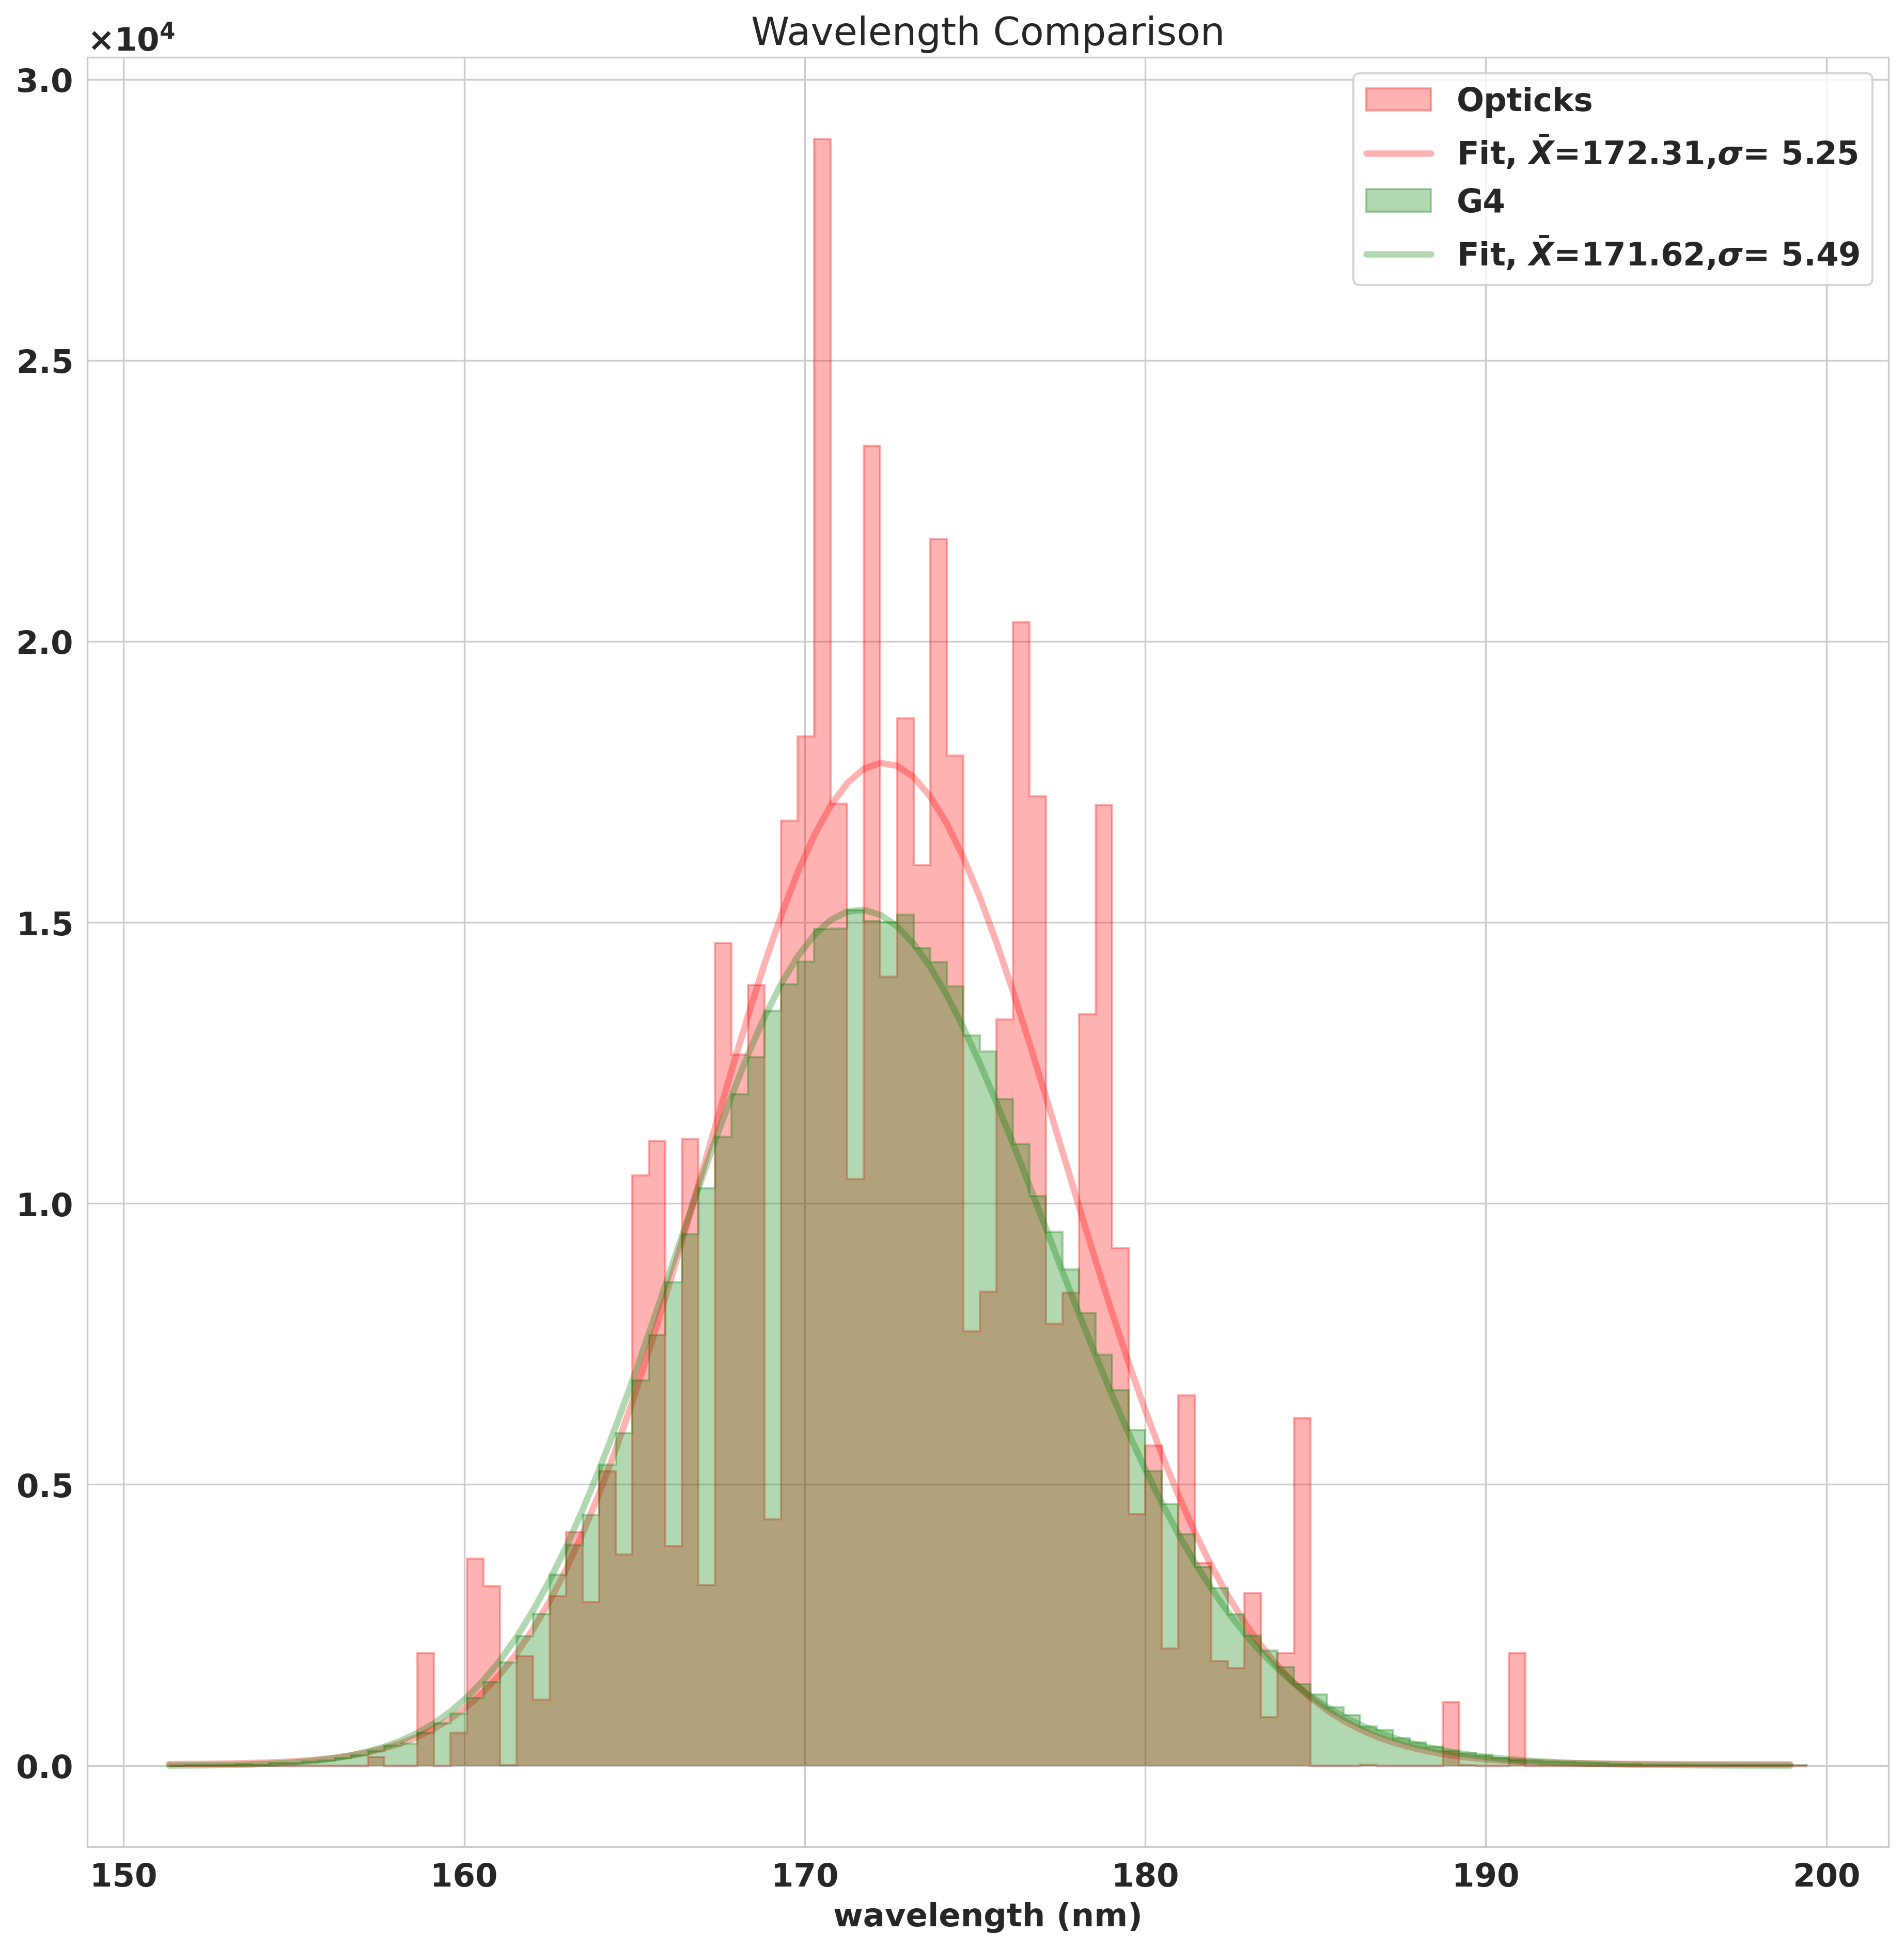

In [69]:
wMax=np.max(np.array([np.max(G4Hits["wavelength"]),np.max(OpticksHits["wavelength"])]))
wMin=np.min(np.array([np.min(G4Hits["wavelength"]),np.min(OpticksHits["wavelength"])]))

plt.figure(figsize=(15,15),dpi=300)
bins_=np.linspace(wMin,wMax,100)
plt.title("Wavelength Comparison")
h1=plt.hist(OpticksHits["wavelength"],bins=bins_,alpha=0.3,label="Opticks",color="red",histtype="step",fill=True)
FitHist1D(h1,plt,"Fit","red",0.3)
#FitHist1D(OpticksHits["wavelength"],plt,"Fit","red",0.3,FitsType="data")

h2=plt.hist(G4Hits["wavelength"],bins=bins_,alpha=0.3,label="G4",color="green",histtype="step",fill=True)
FitHist1D(h2,plt,"Fit","green",0.3)
#FitHist1D(G4Hits["wavelength"],plt,"Fit","green",0.3,FitsType="data")

plt.xlabel("wavelength (nm)")
plt.ticklabel_format(axis='y',style='sci',scilimits=(0,0),useMathText=True)

plt.legend()
if(isSafeFiles):





    plt.savefig(f"{SavePath}/S1_Hit_Wavelength.png")
del h1,h2


Initials (28945.0, 172.63564771503547, 8.041804797471636, 0, 0)
{'Amp': 17818.21, 'u': 172.31, 'sigma': 5.25, 'offset': 0.01}
Initials (15227.0, 173.2244498418597, 9.258241721716564, 0, 0)
{'Amp': 15229.67, 'u': 171.62, 'sigma': 5.49, 'offset': 0.03}


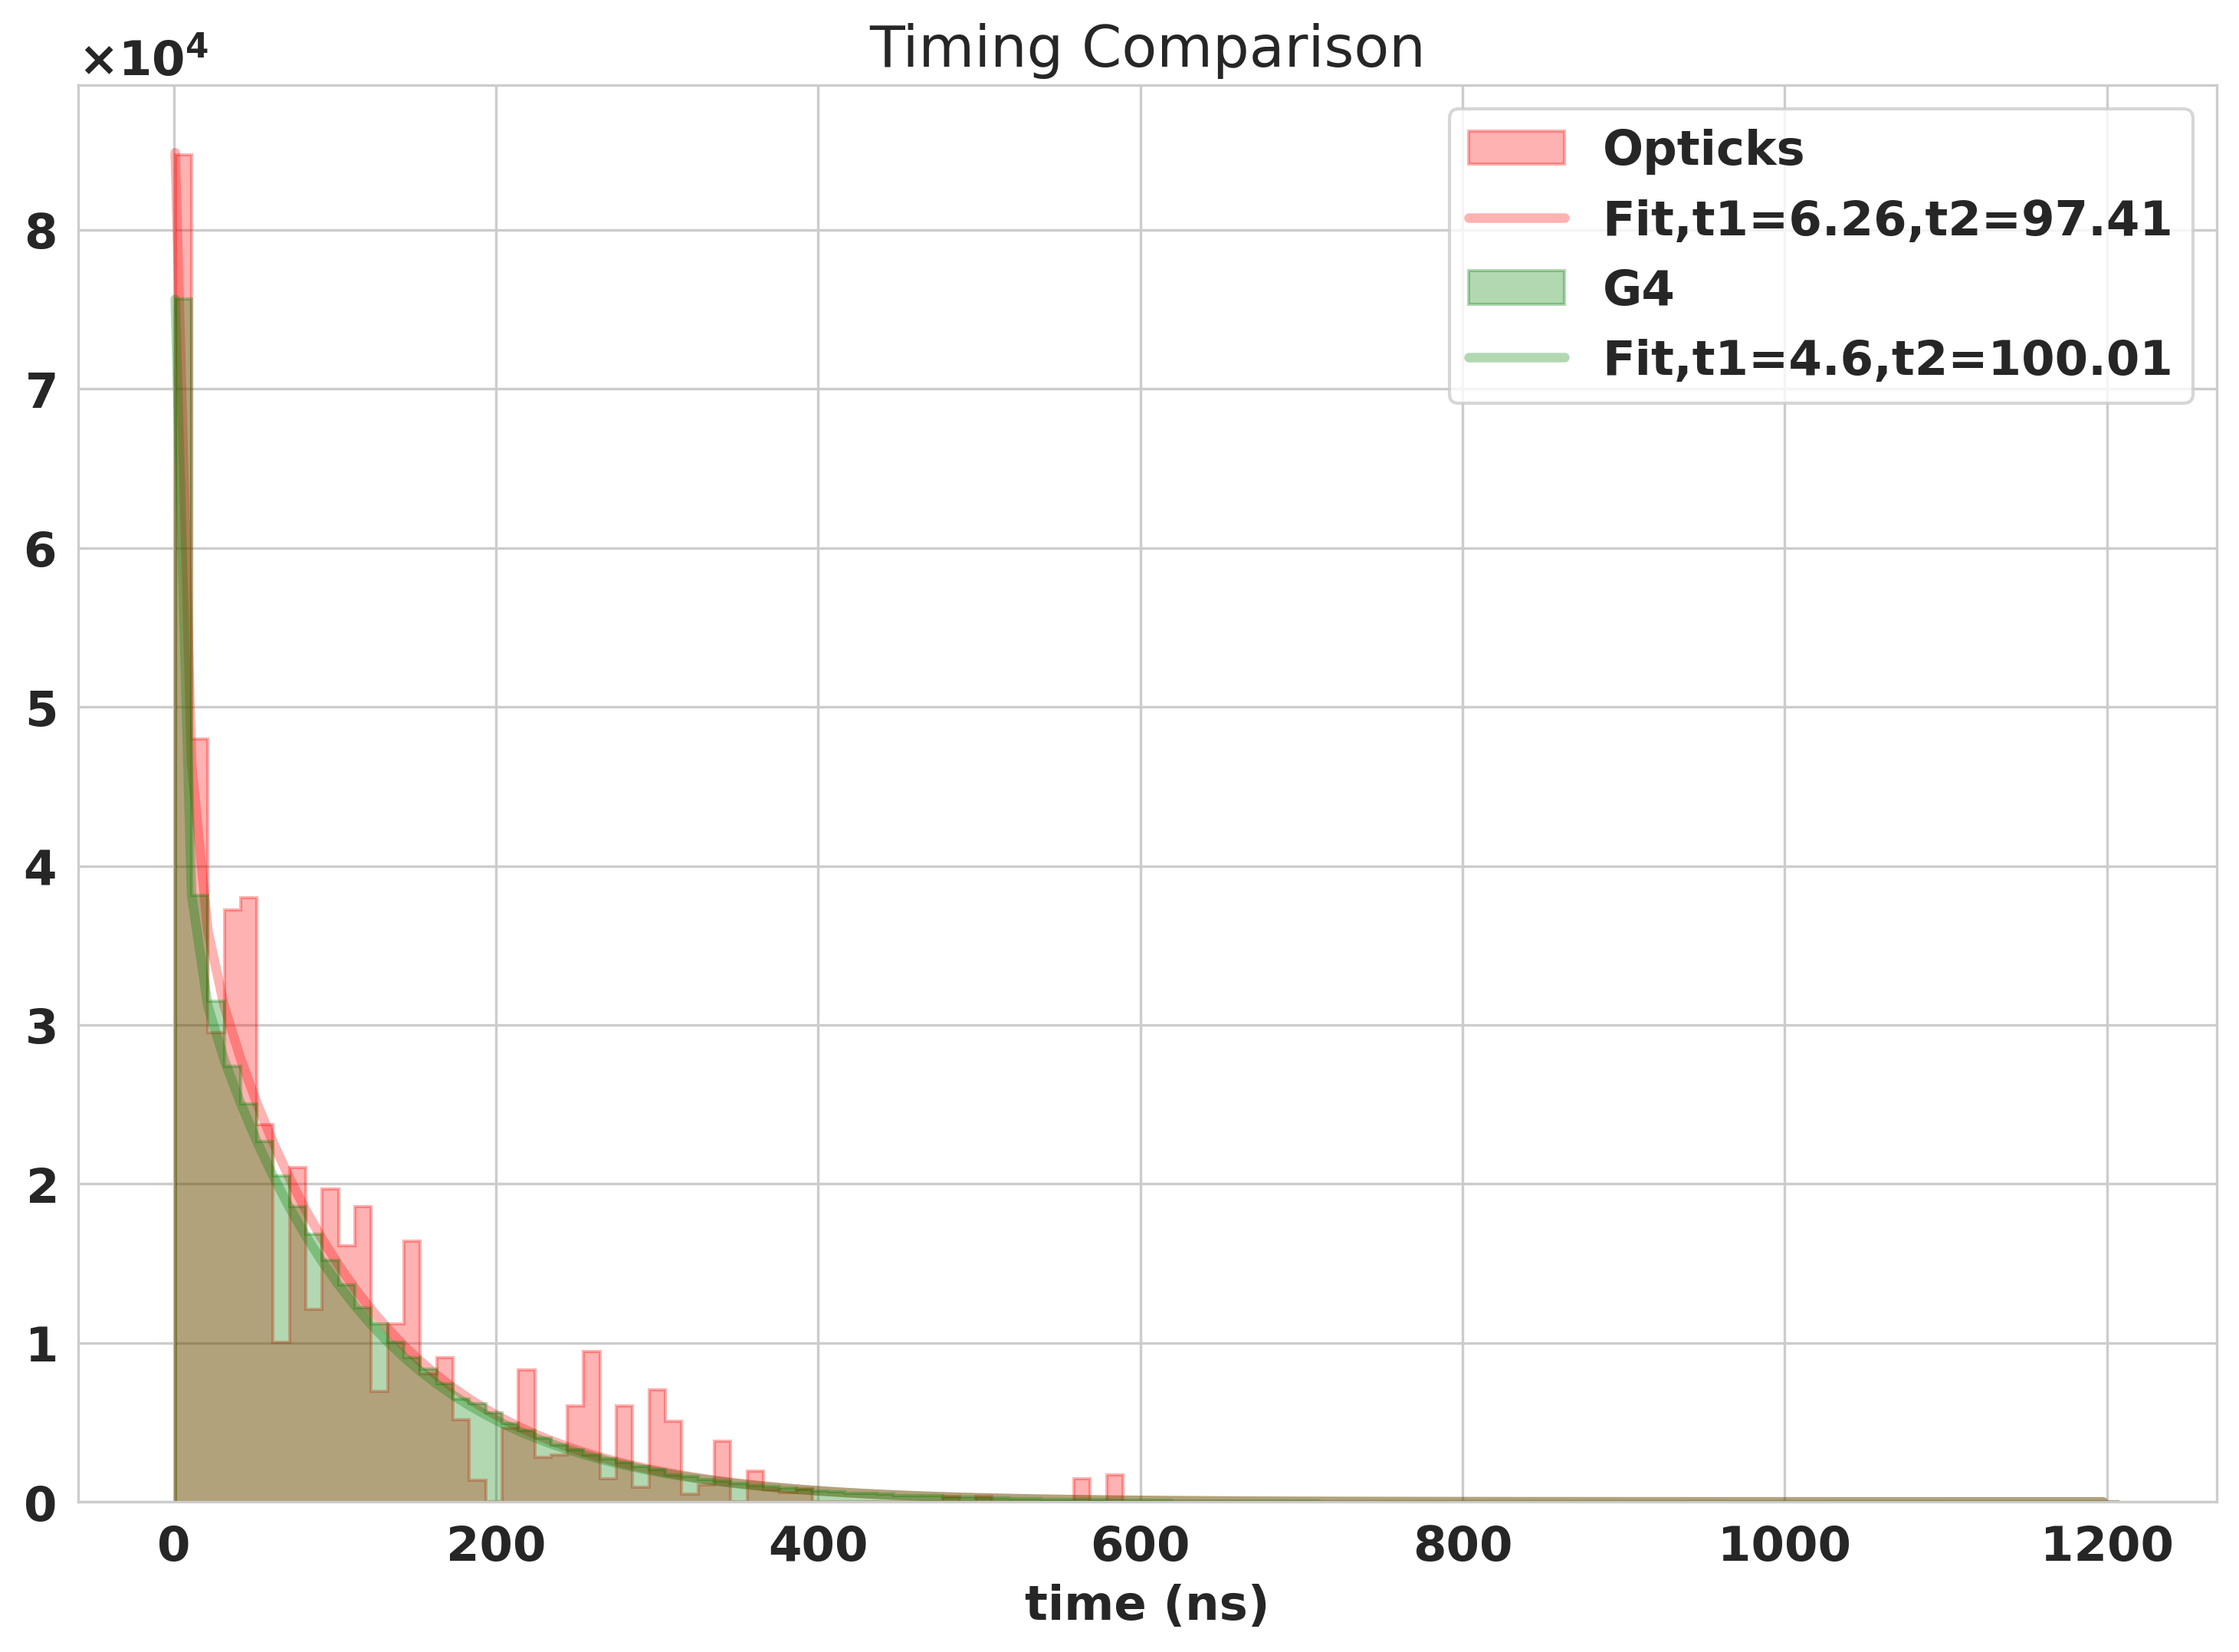

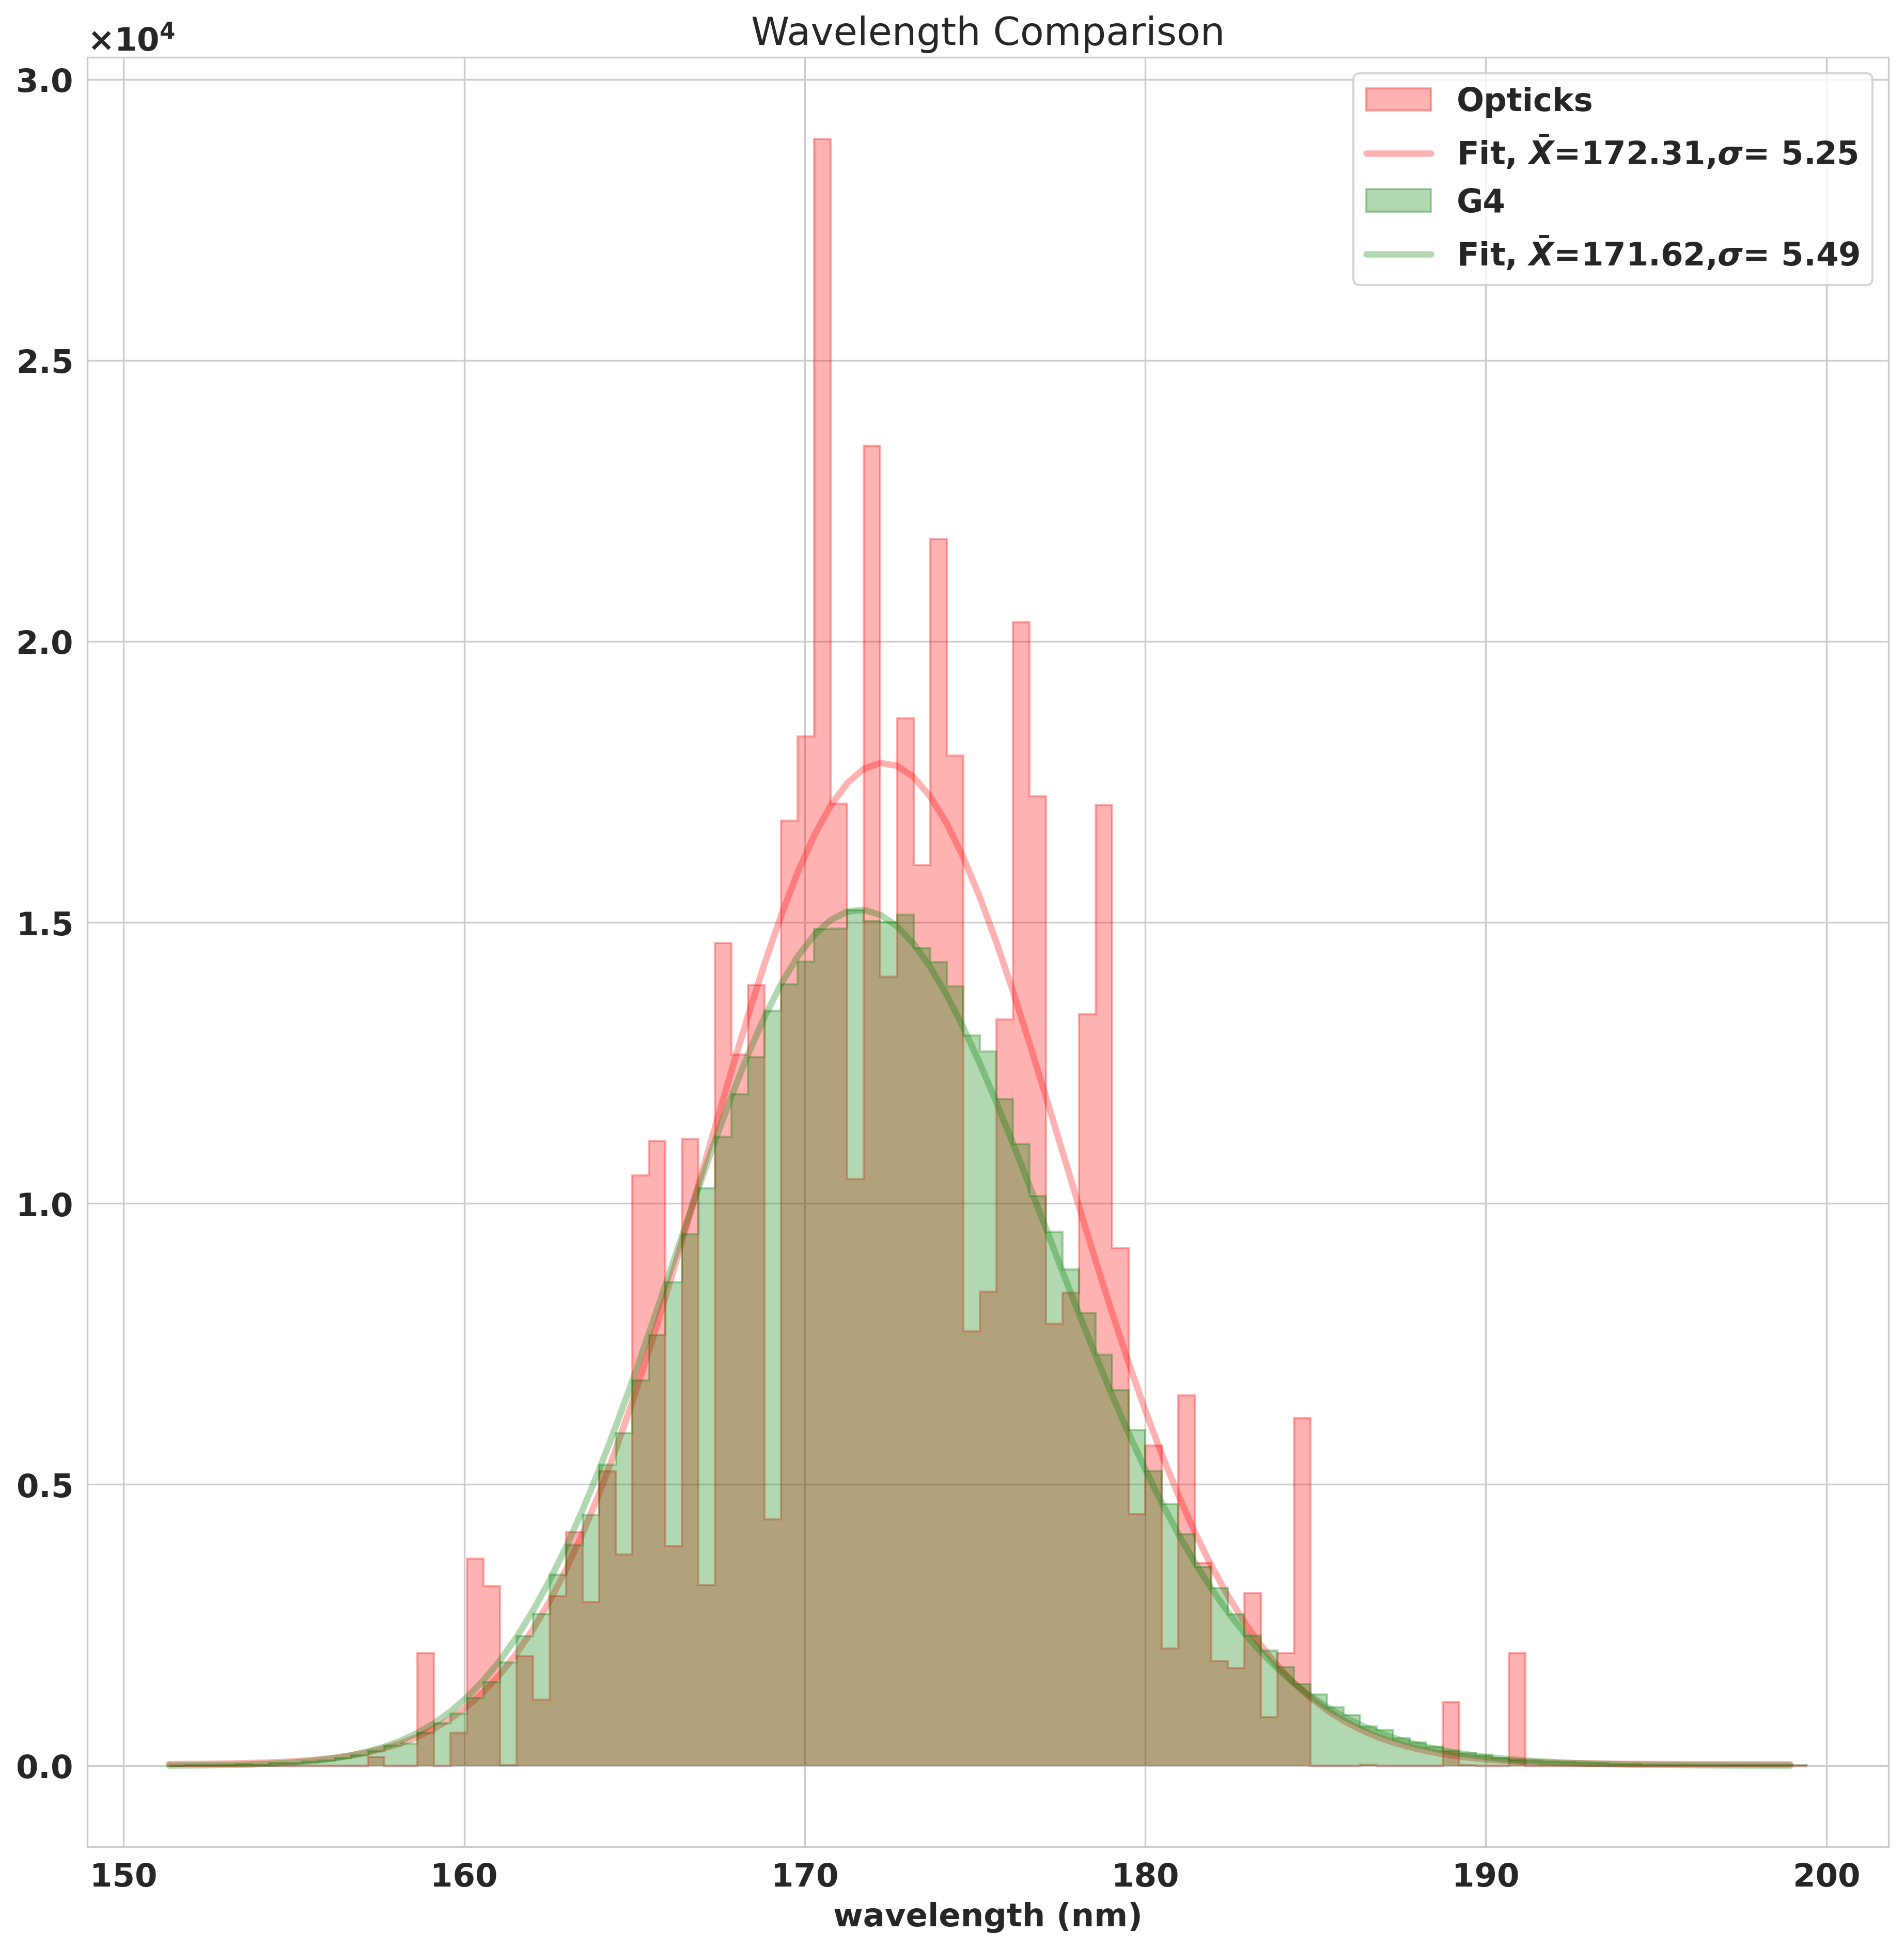

In [70]:
G4HitTime=G4Hits["time"]
OpticksHitTime=OpticksHits["time"]
wMax=np.max(np.array([np.max(G4HitTime),np.max(OpticksHitTime)]))
wMin=np.min(np.array([np.min(G4HitTime),np.min(OpticksHitTime)]))
plt.figure(figsize=(12,8),dpi=300)
bins_=np.linspace(wMin,wMax,120)
plt.title("Timing Comparison")
h1=plt.hist(OpticksHitTime,bins=bins_,alpha=0.3,label="Opticks",color="red",histtype="step",fill=True)
FitExp(h1,plt,"Fit","red",0.3)
#FitExp(OpticksHitTime,plt,"Fit","red",0.3,fitType=["",np.mean(h1[0])])

h2=plt.hist(G4HitTime,bins=bins_,alpha=0.3,label="G4",color="green",histtype="step",fill=True)
FitExp(h2,plt,"Fit","Green",0.3)
#FitExp(G4HitTime,plt,"Fit","Green",0.3,fitType=["",np.mean(h2[0])])
plt.ticklabel_format(axis='y',style='sci',scilimits=(0,0),useMathText=True)
#plt.xlim(80000,wMax)
plt.xlabel("time (ns)")
plt.legend()
wMax = np.max(np.array([np.max(G4Hits["wavelength"]), np.max(OpticksHits["wavelength"])]))
wMin = np.min(np.array([np.min(G4Hits["wavelength"]), np.min(OpticksHits["wavelength"])]))

plt.figure(figsize=(15, 15), dpi=300)
bins_ = np.linspace(wMin, wMax, 100)
plt.title("Wavelength Comparison")
h1 = plt.hist(OpticksHits["wavelength"], bins=bins_, alpha=0.3, label="Opticks", color="red", histtype="step",
              fill=True)
FitHist1D(h1, plt, "Fit", "red", 0.3)
h2 = plt.hist(G4Hits["wavelength"], bins=bins_, alpha=0.3, label="G4", color="green", histtype="step", fill=True)
FitHist1D(h2, plt, "Fit", "green", 0.3)

plt.xlabel("wavelength (nm)")
plt.ticklabel_format(axis='y', style='sci', scilimits=(0, 0), useMathText=True)

plt.legend()
if (isSafeFiles):
    plt.savefig(f"{SavePath}/S1_Hit_Timing.png")

del h1,h2

In [71]:
OpticksHits['event_id']

array([   0,    0,    0, ..., 1999, 1999, 1999])

In [72]:
## Opticks
#OpticksPMTMask=OpticksHits['boundary']==31 ##PMT
#OpticksCamMask=OpticksHits['boundary']==30 ##Camera
## Opticks
#OpticksPMTMask=OpticksHits['boundary']==31 ##PMT
#OpticksCamMask=OpticksHits['boundary']==30 ##Camera
## Geant4
Geant4PMTMask=G4Hits['name']==b'PMTWindow' ##PMT
Geant4CamMask=G4Hits['name']==b'camWindow' ##Camera

OpticksPMTMask=(OpticksHits['z']<100)    ##PMT
OpticksCamMask=(OpticksHits['z']>200)  ##Camera
bnd=[np.unique(OpticksHits['boundary'][OpticksPMTMask]),np.unique(OpticksHits['boundary'][OpticksCamMask])]
print(bnd)
if(len(bnd[0])>1 or len(bnd[1])>1):
    print("Boundary issue ")
    bnd=[bnd[0],bnd[1]]



[array([31], dtype=uint32), array([29], dtype=uint32)]


(array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]),
 array([-1.26766138e+01, -1.25497873e+01, -1.24229607e+01, -1.22961341e+01,
        -1.21693076e+01, -1.20424810e+01, -1.19156545e+01, -1.17888279e+01,
        -1.16620014e+01, -1.15351748e+01, -1.14083483e+01, -1.12815217e+01,
        -1.11546952e+01, -1.10278686e+01, -1.09010421e+01, -1.07742155e+01,
        -1.06473890e+01, -1.05205624e+01, -1.03937358e+01, -1.02669093e+01,
        -1.01400827e+01, -1.00132562e+01, -9.88642963e+00, -9.75960308e+00,
        -9.63277653e+00, -9.50594997e+00, -9.37912342e+00, -9.25229687e+00,
        -9.12547031e+00, -8.99864376e+00, -8.87181721e+00, -8.74499065e+00,
        -8.61816410e+00, -8.49133755e+00, -8.36451099e+00, -8.23768444e+00,
        -8.11085789e+00, -7.98403133e+00, -7.85720478e+00, -7.73037

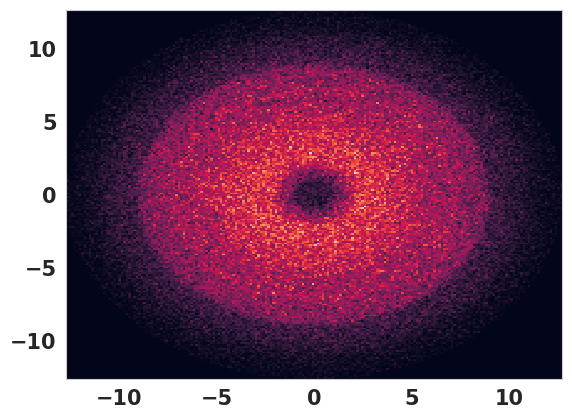

In [73]:
plt.hist2d(G4Hits["x"][Geant4PMTMask], G4Hits["y"][Geant4PMTMask], bins=200)

(array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]),
 array([-12.59300995, -12.46755869, -12.34210744, -12.21665618,
        -12.09120493, -11.96575367, -11.84030242, -11.71485116,
        -11.58939991, -11.46394866, -11.3384974 , -11.21304615,
        -11.08759489, -10.96214364, -10.83669238, -10.71124113,
        -10.58578987, -10.46033862, -10.33488736, -10.20943611,
        -10.08398485,  -9.9585336 ,  -9.83308234,  -9.70763109,
         -9.58217983,  -9.45672858,  -9.33127732,  -9.20582607,
         -9.08037481,  -8.95492356,  -8.8294723 ,  -8.70402105,
         -8.57856979,  -8.45311854,  -8.32766728,  -8.20221603,
         -8.07676477,  -7.95131352,  -7.82586226,  -7.70041101,
         -7.57495975,  -7.4495085 ,  -7.32405725,  -7.19860599,
         -7.07315474,  -6.94770348,  -6.8222522

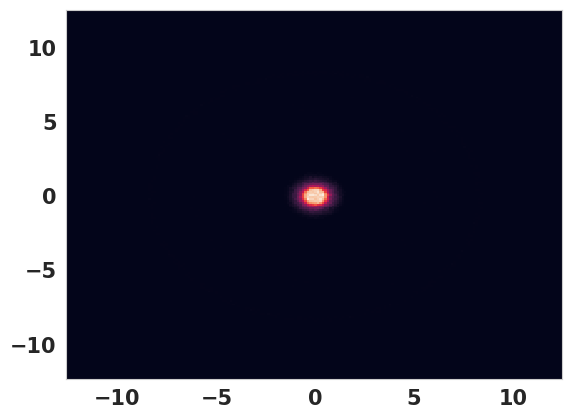

In [74]:
plt.hist2d(G4Hits["x"][Geant4CamMask],G4Hits["y"][Geant4CamMask],bins=200)

337570


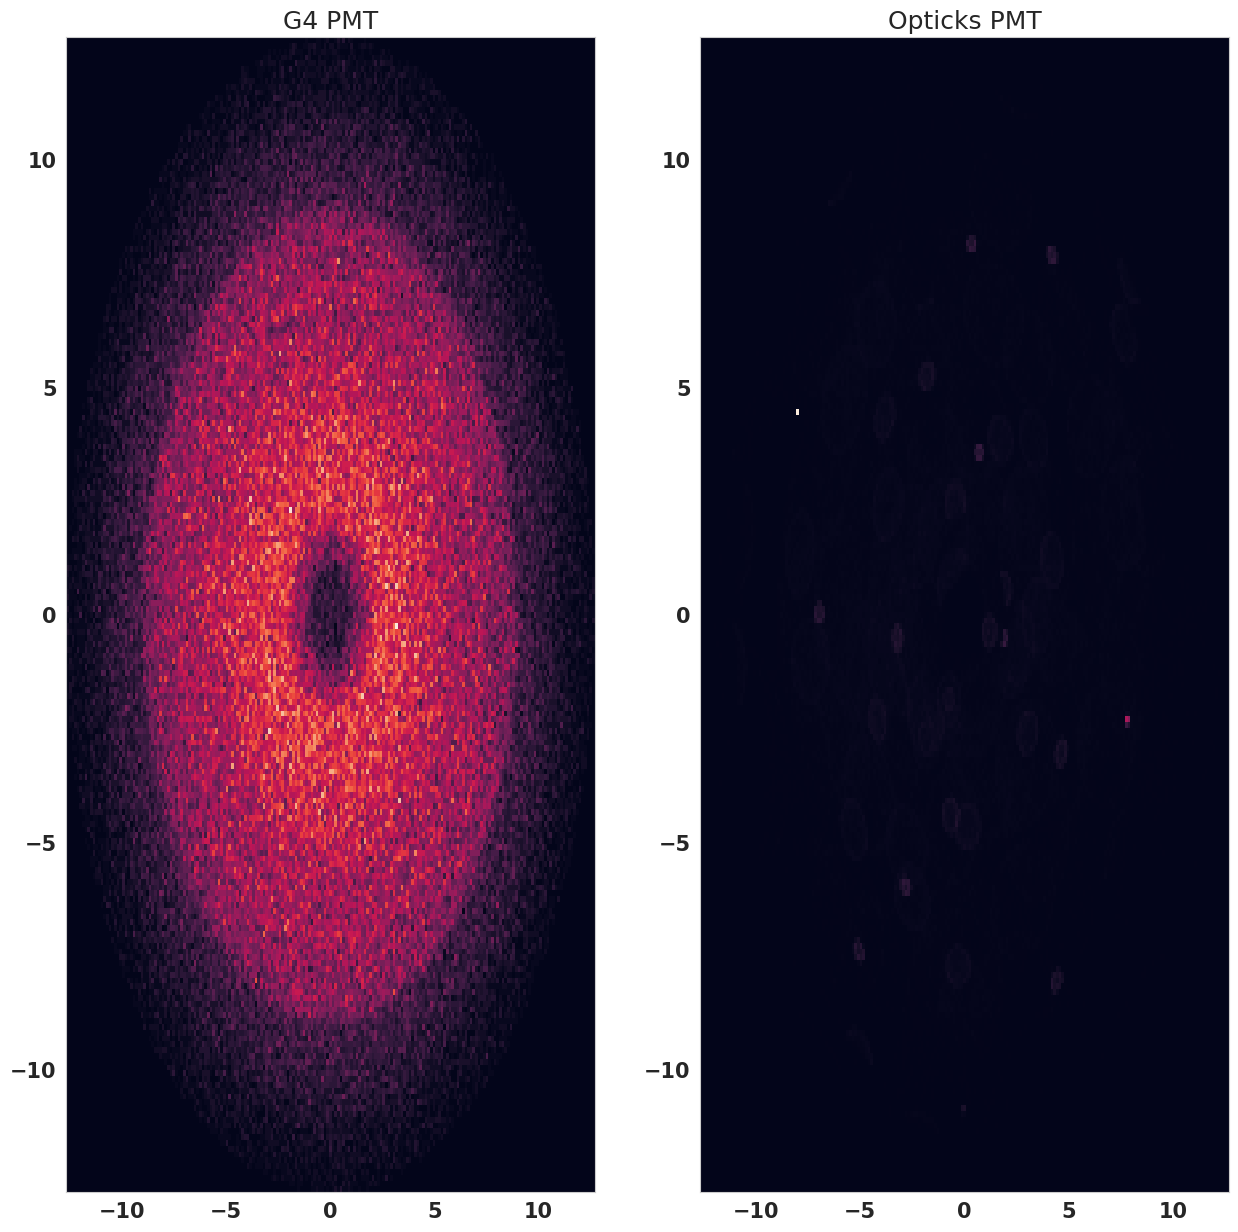

<Figure size 7500x7500 with 0 Axes>

In [75]:
fig,ax=plt.subplots(1,2)
fig.set_figheight(15)
fig.set_figwidth(15)
Binsize=200
G4X=G4Hits["x"][Geant4PMTMask]
G4Y=G4Hits["y"][Geant4PMTMask]
print(len(G4X))
OX=OpticksHits['x'][OpticksPMTMask]
OY=OpticksHits['y'][OpticksPMTMask]

maXX=np.max(np.array([np.max(G4X),np.max(OX)]))
miNX=np.min(np.array([np.min(G4X),np.min(OX)]))
lins1X=np.linspace(miNX,maXX,Binsize)

maXY=np.max(np.array([np.max(G4Y),np.max(OY)]))
miNY=np.min(np.array([np.min(G4Y),np.min(OY)]))
lins1Y=np.linspace(miNY,maXY,Binsize)
plt.figure(figsize=(25,25),dpi=300)
ax[0].set_title("G4 PMT")
ax[0].hist2d(G4X,G4Y,bins=[lins1X,lins1Y],label="G4")
ax[1].set_title("Opticks PMT")
ax[1].hist2d(OX,OY,bins=[lins1X,lins1Y],label="Opticks")

plt.show()

In [76]:
def PlotFit1D(xval,yval,ax,title,type="Gauss",bin=100,colors=["red","green"],labels=["Opticks","Geant4"],axislabels=["Frequency","Wavelength (nm)"]):
    wMax=np.max(np.array([np.max(xval),np.max(yval)]))
    wMin=np.min(np.array([np.min(xval),np.min(yval)]))
    
    bins_=np.linspace(wMin,wMax,bin)
    ax.set_title(title)
    h1=ax.hist(xval,bins=bins_,alpha=0.3,label=labels[0],color=colors[0],edgecolor=colors[0],histtype="step",fill=True)
    FitHist1D(h1,ax,"Fit",colors[0],0.5) if (type=="Gauss") else FitExp(h1,ax,"Fit",colors[0],0.5) 

    
    h2=ax.hist(yval,bins=bins_,alpha=0.3,label=labels[1],histtype="step",fill=True,color=colors[1],edgecolor=colors[1])
    FitHist1D(h2,ax,"Fit",colors[1],0.5) if (type=="Gauss") else FitExp(h2,ax,"Fit",colors[1],0.5) 
   
    ax.set_xlabel(axislabels[1])
    ax.set_ylabel(axislabels[0])
    ax.legend()
    ax.ticklabel_format(axis='y',style='sci',scilimits=(0,0),useMathText=True)
    del h1,h2

def Plot2D_JointPlot(valO,ValG4,FileName,Title,Binsize=200,histBin=500, isPlottext=False,isHistType="numpy",isCameraView=False):
    if(isCameraView):
         x=valO[0]
         y=valO[1]
         #z=Z[Mask]
         theta=-np.pi/7
         costet=np.cos(theta)
         sintet=np.sin(theta)
         pixelsize=0.016
    
         XRotated=(x*costet-sintet*y)
         YRotated=-(x*sintet+costet*y)
    
         #XRotated=((XRotated)/(pixelsize*3.5))+260+10
         #YRotated=((YRotated)/(pixelsize*3.5)+230+40)
         XRotated=((XRotated)/(pixelsize*3.7))+260-20
         YRotated=((YRotated)/(pixelsize*3.7)+230+60)
         valO[0]=np.array(XRotated)
         valO[1]=np.array(YRotated)
        
         x=ValG4[0]
         y=ValG4[1]
         #z=Z[Mask]
         theta=-np.pi/7
         costet=np.cos(theta)
         sintet=np.sin(theta)
         pixelsize=0.016
    
         XRotated=(x*costet-sintet*y)
         YRotated=-(x*sintet+costet*y)
    
         #XRotated=((XRotated)/(pixelsize*3.5))+260+10
         #YRotated=((YRotated)/(pixelsize*3.5)+230+40)
         XRotated=((XRotated)/(pixelsize*3.7))+260-20
         YRotated=((YRotated)/(pixelsize*3.7)+230+60)
         ValG4[0]=np.array(XRotated)
         ValG4[1]=np.array(YRotated)
    maXX=np.max(np.array([np.max(ValG4[0]),np.max(valO[0])]))
    miNX=np.min(np.array([np.min(ValG4[0]),np.min(valO[0])]))
    lins1X=np.linspace(miNX,maXX,Binsize)
    
    maXY=np.max(np.array([np.max(ValG4[1]),np.max(valO[1])]))
    miNY=np.min(np.array([np.min(ValG4[1]),np.min(valO[1])]))
    lins1Y=np.linspace(miNY,maXY,Binsize)
    
    G4Dict={"x(mm)":ValG4[0],"y(mm)":ValG4[1]}
    OpticksDict={"x(mm)":valO[0],"y(mm)":valO[1]}
    plt.figure(figsize=(15,15),dpi=300)
    g=sns.jointplot(data=G4Dict,x="x(mm)", y="y(mm)", kind='hist',bins=[lins1X,lins1Y],marginal_kws={"bins":lins1X,"kde":True},cmap="viridis",color="green",height=10,cbar=True,cbar_kws={"use_gridspec":False, "location":"top","aspect":50,"fraction":0.016,"pad":0,"aspect":50});
    #plt.hist2d(ValG4[0], ValG4[1], bins=[lins1X,lins1Y], cmap="viridis",norm=LogNorm());
    x=0
    y=0
    fitx=0
    fity=0
    if(isPlottext):
        binX=np.linspace(np.min(ValG4[0]),np.max(ValG4[0]),histBin)
        binY=np.linspace(np.min(ValG4[1]),np.max(ValG4[1]),histBin)
        if(isHistType=="numpy"):
            x=np.histogram(ValG4[0], bins=binX)
            y=np.histogram(ValG4[1], bins=binY)
            fitx=FitHist1D(x,None,"x","red",0.5)
            fity=FitHist1D(y,None,"y","green",0.5)
        else:
            x=np.histogram(ValG4[0], bins=binX)
            y=np.histogram(ValG4[1], bins=binY)
            x=plt.hist(ValG4[0], bins=lins1X)
            y=np.histogram(ValG4[1], bins=lins1Y)
            fitx=FitHist1D(x,plt,"x","red",0.5)
            fity=FitHist1D(y,plt,"y","green",0.5)
            plt.xlim(-5,5)
        g.ax_marg_x.axvspan(fitx["u"] - fitx["sigma"],fitx["u"] + fitx["sigma"], color='gray', alpha=0.35)
    
        g.ax_marg_y.axhspan(fity["u"] - fity["sigma"], fity["u"] + fity["sigma"], color='gray', alpha=0.35)
        g.refline(x=fitx["u"], y=fity["u"], color='green', ls='--',alpha=0.4)
        ## Place the Values to Cells
        ax_marg_x = g.ax_marg_x
        Ydata= g.ax_marg_x.get_yticks()
        Xdata= g.ax_marg_y.get_yticks()
        ax_marg_y = g.ax_marg_y
        ## Place  the text to Marginal X axis
        #print(x_mean,x_std)
        XMean=fitx["u"]
        YMean=fity["u"]
        Xsig=fitx["sigma"]
        Ysig=fity["sigma"]
        labelX_str=r'$\bar{X}$' + f" = {str(XMean)}, " + r'$\sigma_{X}$'+f" = {str(Xsig)}"
        labelY_str=r'$\bar{Y}$' + f" = {str(YMean)}, \n " + r'$\sigma_{Y}$'+f" = {str(Ysig)}"
        ## Mean and STD for X and Y
        ax_marg_x.text(XMean+ 2*Xsig, np.mean(Ydata), labelX_str, fontsize=12)
        ax_marg_y.text( np.mean(Xdata),YMean + 2*Ysig, labelY_str, fontsize=12)
        
    
    #g.plot_joint(sns.kdeplot, color="red", zorder=0, alpha=0.3,levels=6)
    #g.plot_marginals(sns.rugplot,  color="red", height=+.02, clip_on=False)
    plt.suptitle(Title[1],fontweight="bold",ha="left",size="medium")
    if (isSafeFiles):
        plt.savefig(f"{SavePath}/{FileName[1]}.png")
        
    g=sns.jointplot(data=OpticksDict,x="x(mm)",y= "y(mm)" ,kind='hist',cmap="viridis",bins=[lins1X,lins1Y],marginal_kws={"bins":Binsize,"kde":True},color="red",height=10,cbar=True,cbar_kws={"use_gridspec":True,"fraction":0.016,"pad":0,"location":"top","aspect":50});
    
    #g.plot_joint(sns.kdeplot,  color="green",alpha=0.3, zorder=0, levels=6)
    #g.plot_marginals(sns.rugplot,  color="green", height=+.02, clip_on=False)
    #plt.hist2d(valO[0], valO[1], bins=[lins1X,lins1Y], cmap="viridis",norm=LogNorm());
    x=0
    y=0
    fitx=0
    fity=0
    if(isPlottext):
        binX=np.linspace(np.min(valO[0]),np.max(valO[0]),histBin)
        binY=np.linspace(np.min(valO[1]),np.max(valO[1]),histBin)
        if(isHistType=="numpy"):
            x=np.histogram(valO[0], bins=binX)
            y=np.histogram(valO[1], bins=binY)
            fitx=FitHist1D(x,None,"x","red",0.5)
            fity=FitHist1D(y,None,"y","green",0.5)
        else:
            x=np.histogram(valO[0], bins=binX)
            y=np.histogram(valO[1], bins=binY)
            fitx=FitHist1D(x,plt,"x","red",0.5)
            fity=FitHist1D(y,plt,"y","green",0.5)
            plt.xlim(-5,5)
    
    
        
        g.ax_marg_x.axvspan(fitx["u"] - fitx["sigma"],fitx["u"] + fitx["sigma"], color='gray', alpha=0.35)
    
        g.ax_marg_y.axhspan(fity["u"] - fity["sigma"], fity["u"] + fity["sigma"], color='gray', alpha=0.35)
        g.refline(x=fitx["u"], y=fity["u"], color='green', ls='--',alpha=0.4)
        ## Place the Values to Cells
        ax_marg_x = g.ax_marg_x
        Ydata= g.ax_marg_x.get_yticks()
        Xdata= g.ax_marg_y.get_yticks()
        ax_marg_y = g.ax_marg_y
        ## Place  the text to Marginal X axis
        #print(x_mean,x_std)
        XMean=fitx["u"]
        YMean=fity["u"]
        Xsig=fitx["sigma"]
        Ysig=fity["sigma"]
        labelX_str=r'$\bar{X}$' + f" = {str(XMean)}, " + r'$\sigma_{X}$'+f" = {str(Xsig)}"
        labelY_str=r'$\bar{Y}$' + f" = {str(YMean)}, \n " + r'$\sigma_{Y}$'+f" = {str(Ysig)}"
        ## Mean and STD for X and Y
        ax_marg_x.text(XMean+ 2*Xsig, np.mean(Ydata), labelX_str, fontsize=12)
        ax_marg_y.text( np.mean(Xdata),YMean + 2*Ysig, labelY_str, fontsize=12)
    
    plt.suptitle(Title[0],fontweight="bold",ha="left",size="medium")
    if (isSafeFiles):
        plt.savefig(f"{SavePath}/{FileName[0]}.png")
    del g    

def Plot2D_JointPlot_Old(valO,ValG4,FileName,Title,Binsize=200,isPlottext=False,vnorm=None,isCameraView=False,labels=["x(mm)","y(mm)"]):
    
    if(isCameraView):
        x=valO[0]
        y=valO[1]
        #z=Z[Mask]
        theta=-np.pi/7
        costet=np.cos(theta)
        sintet=np.sin(theta)
        pixelsize=0.016
    
        XRotated=(x*costet-sintet*y)
        YRotated=-(x*sintet+costet*y)
    
        #XRotated=((XRotated)/(pixelsize*3.5))+260+10
        #YRotated=((YRotated)/(pixelsize*3.5)+230+40)
        XRotated=((XRotated)/(pixelsize*3.7))+260-20
        YRotated=((YRotated)/(pixelsize*3.7)+230+60)
        valO[0]=np.array(XRotated)
        valO[1]=np.array(YRotated)
        
        x=ValG4[0]
        y=ValG4[1]
        #z=Z[Mask]
        theta=-np.pi/7
        costet=np.cos(theta)
        sintet=np.sin(theta)
        pixelsize=0.016
    
        XRotated=(x*costet-sintet*y)
        YRotated=-(x*sintet+costet*y)
    
        #XRotated=((XRotated)/(pixelsize*3.5))+260+10
        #YRotated=((YRotated)/(pixelsize*3.5)+230+40)
        XRotated=((XRotated)/(pixelsize*3.7))+260-20
        YRotated=((YRotated)/(pixelsize*3.7)+230+60)
        ValG4[0]=np.array(XRotated)
        ValG4[1]=np.array(YRotated)
    maXX=np.max(np.array([np.max(ValG4[0]),np.max(valO[0])]))
    miNX=np.min(np.array([np.min(ValG4[0]),np.min(valO[0])]))
    lins1X=np.linspace(miNX,maXX,Binsize)
    
    maXY=np.max(np.array([np.max(ValG4[1]),np.max(valO[1])]))
    miNY=np.min(np.array([np.min(ValG4[1]),np.min(valO[1])]))
    lins1Y=np.linspace(miNY,maXY,Binsize)
    
    G4Dict={labels[0]:ValG4[0],labels[1]:ValG4[1]}
    OpticksDict={labels[0]:valO[0],labels[1]:valO[1]}
    plt.figure(figsize=(15,15),dpi=300)
    g=sns.jointplot(data=G4Dict,x=labels[0], y=labels[1], kind='hist',bins=[lins1X,lins1Y],marginal_kws={"bins":Binsize,"kde":True},cmap="viridis",color="green",height=10,cbar=True,cbar_kws={"use_gridspec":False, "location":"top","aspect":50,"fraction":0.016,"pad":0,"aspect":50});
    #plt.hist2d(ValG4[0], ValG4[1], bins=[lins1X,lins1Y], cmap="viridis");
    if(isPlottext):
        x_mean = round(np.mean(ValG4[0]),2)
        x_std = round(np.std(ValG4[0]),2)
        g.ax_marg_x.axvspan(x_mean - x_std, x_mean + x_std, color='gray', alpha=0.35)

        y_mean = round(np.mean(ValG4[1]),2)
        y_std = round(np.std(ValG4[1]),2)
        g.ax_marg_y.axhspan(y_mean - y_std, y_mean + y_std, color='gray', alpha=0.35)
        g.refline(x=x_mean, y=y_mean, color='green', ls='--',alpha=0.4)
        ## Place the Values to Cells
        ax_marg_x = g.ax_marg_x
        Ydata= g.ax_marg_x.get_yticks()
        Xdata= g.ax_marg_y.get_yticks()
        ax_marg_y = g.ax_marg_y
        ## Place  the text to Marginal X axis
        print(x_mean,x_std)
        labelX_str=r'$\bar{X}$' + f" = {str(x_mean)}, " + r'$\sigma_{X}$'+f" = {str(x_std)}"
        labelY_str=r'$\bar{Y}$' + f" = {str(y_mean)}, \n " + r'$\sigma_{Y}$'+f" = {str(y_std)}"
        ## Mean and STD for X and Y
        ax_marg_x.text(x_mean + 2*x_std, np.mean(Ydata), labelX_str, fontsize=12)
        ax_marg_y.text( np.mean(Xdata),y_mean + 2*y_std, labelY_str, fontsize=12)
        
    
    #g.plot_joint(sns.kdeplot, color="red", zorder=0, alpha=0.3,levels=6)
    #g.plot_marginals(sns.rugplot,  color="red", height=+.02, clip_on=False)
    plt.suptitle(Title[1],fontweight="bold",ha="left",size="medium")
    if (isSafeFiles):
        plt.savefig(f"{SavePath}/{FileName[1]}.png")
        
    g=sns.jointplot(data=OpticksDict,x=labels[0],y= labels[1] ,kind='hist',bins=[lins1X,lins1Y],cmap="viridis",marginal_kws={"bins":Binsize,"kde":True},color="red",height=10,cbar=True,cbar_kws={"use_gridspec":True,"fraction":0.016,"pad":0,"location":"top","aspect":50});

    #g.plot_joint(sns.kdeplot,  color="green",alpha=0.3, zorder=0, levels=6)
    #g.plot_marginals(sns.rugplot,  color="green", height=+.02, clip_on=False)

    #if(vnorm!=None):
    #    plt.hist2d(valO[0], valO[1], bins=[lins1X,lins1Y], cmap="viridis",vmin=vnorm[0],vmax=vnorm[1])
    #else:
    #    plt.hist2d(valO[0], valO[1], bins=[lins1X,lins1Y], cmap="viridis")
    
    if(isPlottext):
        x_mean = round(np.mean(valO[0]),2)
        x_std = round(np.std(valO[0]),2)
        g.ax_marg_x.axvspan(x_mean - x_std, x_mean + x_std, color='gray', alpha=0.35)
    
        y_mean = round(np.mean(valO[1]),2)
        y_std = round(np.std(valO[1]),2)
        g.ax_marg_y.axhspan(y_mean - y_std, y_mean + y_std, color='gray', alpha=0.35)
        g.refline(x=x_mean, y=y_mean, color='red', ls='--',alpha=0.3)
        ## Place the Values to Cells
        ax_marg_x = g.ax_marg_x
        Ydata= g.ax_marg_x.get_yticks()
        Xdata= g.ax_marg_y.get_yticks()
        ax_marg_y = g.ax_marg_y
        ## Place  the text to Marginal X axis
        print(x_mean,x_std)
        labelX_str=r'$\bar{X}$' + f" = {str(x_mean)}, "+ r'$\sigma_{X}$'+f" = {str(x_std)}"
        labelY_str=r'$\bar{Y}$' + f" = {str(y_mean)}, \n " + r'$\sigma_{Y}$'+f" = {str(y_std)}"
        ## Mean and STD for X and Y
        ax_marg_x.text(x_mean + 2*x_std, np.mean(Ydata), labelX_str, fontsize=12)
        ax_marg_y.text( np.mean(Xdata),y_mean + 2*y_std, labelY_str, fontsize=12)
    
    plt.suptitle(Title[0],fontweight="bold",ha="left",size="medium")
    if (isSafeFiles):
        plt.savefig(f"{SavePath}/{FileName[0]}.png")

<Figure size 4500x4500 with 0 Axes>

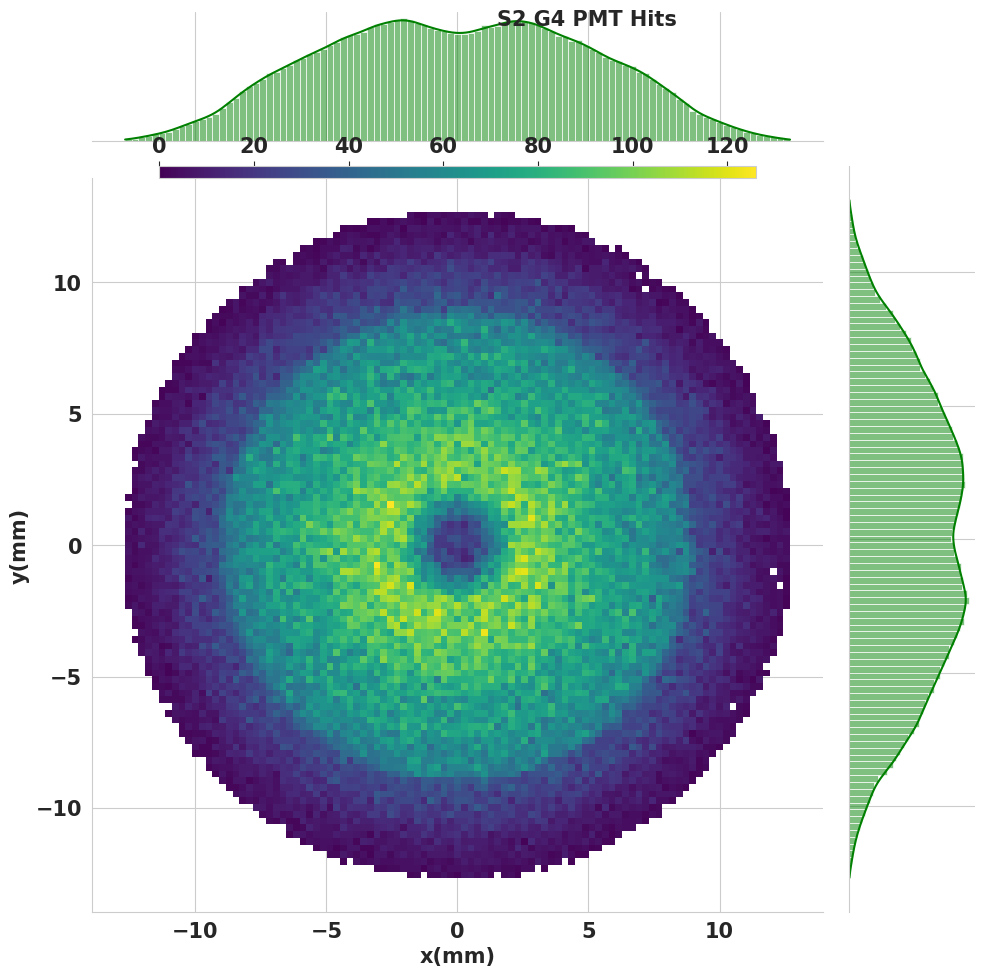

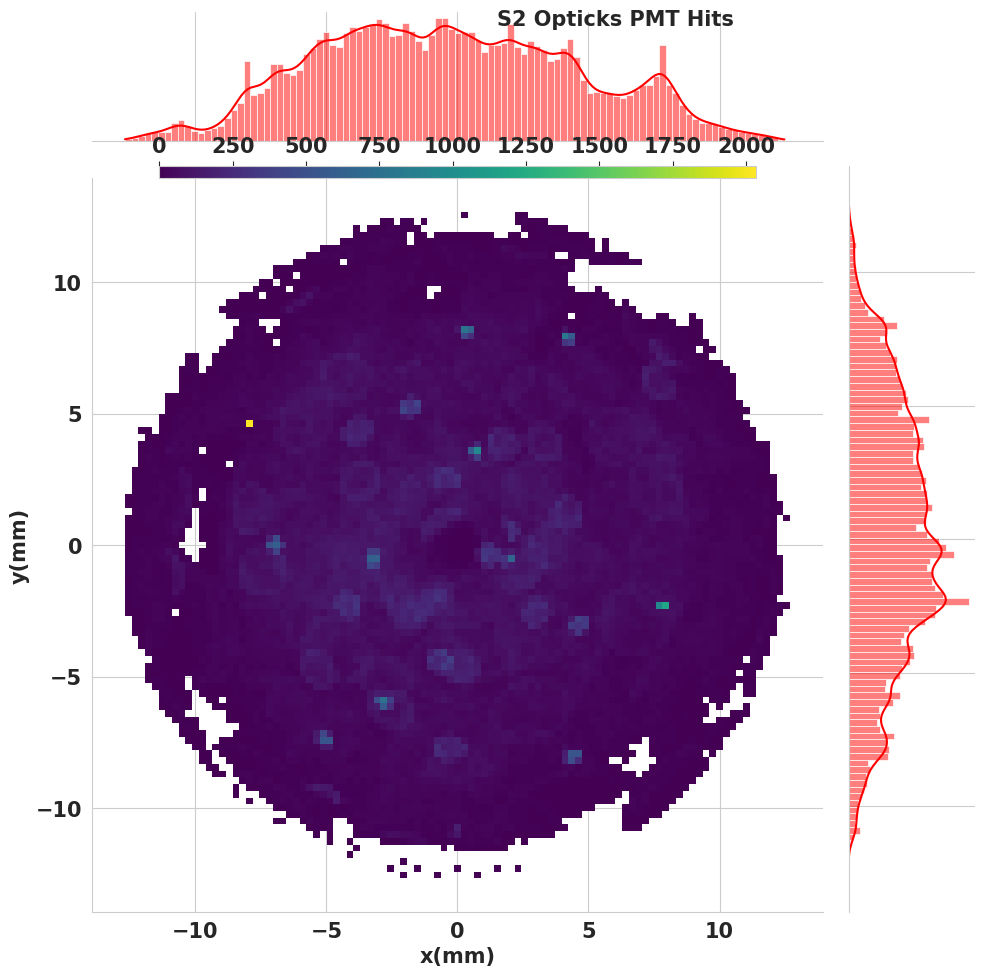

In [77]:
Binsize=100
G4X=G4Hits["x"][Geant4PMTMask]
G4Y=G4Hits["y"][Geant4PMTMask]
OX=OpticksHits['x'][OpticksPMTMask]
OY=OpticksHits['y'][OpticksPMTMask]
### Get S2 PMT Comparison
Plot2D_JointPlot([OX,OY],[G4X,G4Y],["S2_Opticks_PMT_Hits","S2_G4_PMT_Hits"],["S2 Opticks PMT Hits","S2 G4 PMT Hits"],Binsize=Binsize)

Initials (3361, -0.1340140647473388, 4.616623655217462, 0, 0)
{'Amp': 3485.34, 'u': -0.03, 'sigma': 0.52, 'offset': 0.0}
Initials (3499, -0.2818239080802398, 4.414296876680981, 0, 0)
{'Amp': 3533.65, 'u': -0.03, 'sigma': 0.51, 'offset': 0.0}
Initials (4670, -1.6577673104897133, 6.0167933110911385, 0, 0)
{'Amp': 3075.44, 'u': -0.18, 'sigma': 0.65, 'offset': 0.07}
Initials (4040, -0.5972041321347658, 6.036847164298649, 0, 0)
{'Amp': 3195.07, 'u': 0.03, 'sigma': 0.64, 'offset': -0.04}


<Figure size 4500x4500 with 0 Axes>

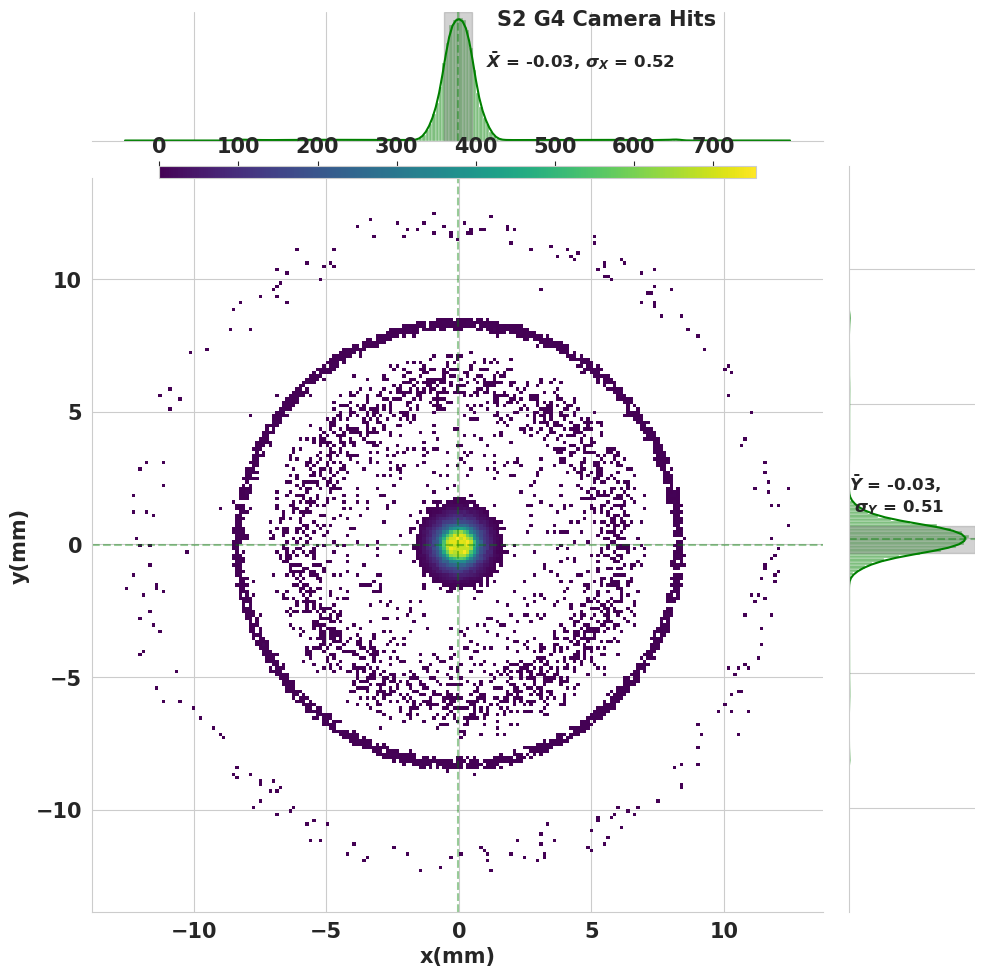

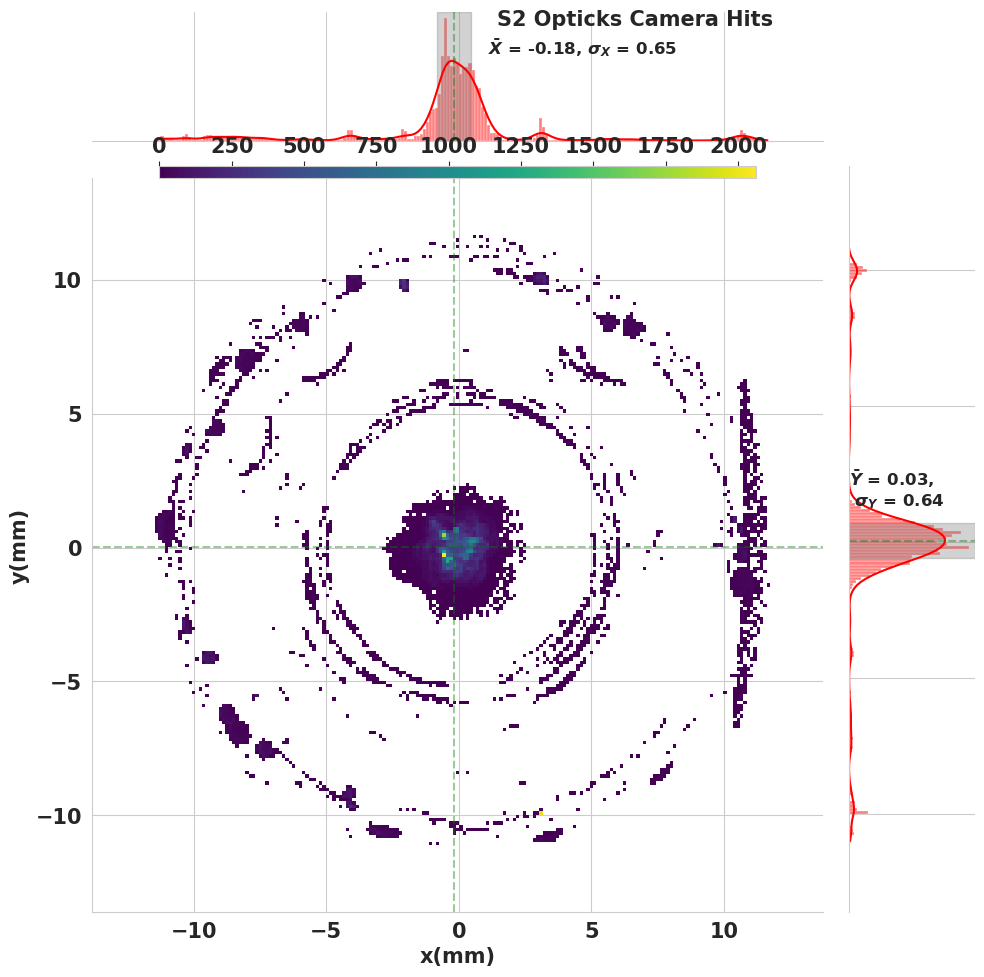

In [78]:

Binsize=200
G4X=G4Hits["x"][Geant4CamMask]
G4Y=G4Hits["y"][Geant4CamMask]
OX=OpticksHits['x'][OpticksCamMask]
OY=OpticksHits['y'][OpticksCamMask]

### Get S1 Camera Comparison
Plot2D_JointPlot([OX,OY],[G4X,G4Y],["S2_Opticks_Camera_Hits","S2_G4_Camera_Hits"],["S2 Opticks Camera Hits","S2 G4 Camera Hits"],isPlottext=True,isCameraView=False,Binsize=Binsize)

In [79]:
def getHits(Hits,Mask):
    unique, counts = np.unique(Hits['event_id'][Mask], return_counts=True)
    return counts

Initials (126.0, 48.34130110009507, 12.078906965735536, 0, 0)
{'Amp': 32.24, 'u': 46.7, 'sigma': 7.0, 'offset': 0.03}
Initials (195.0, 70.25103779768406, 7.387501442731278, 0, 0)
{'Amp': 42.29, 'u': 65.29, 'sigma': 4.18, 'offset': 0.34}


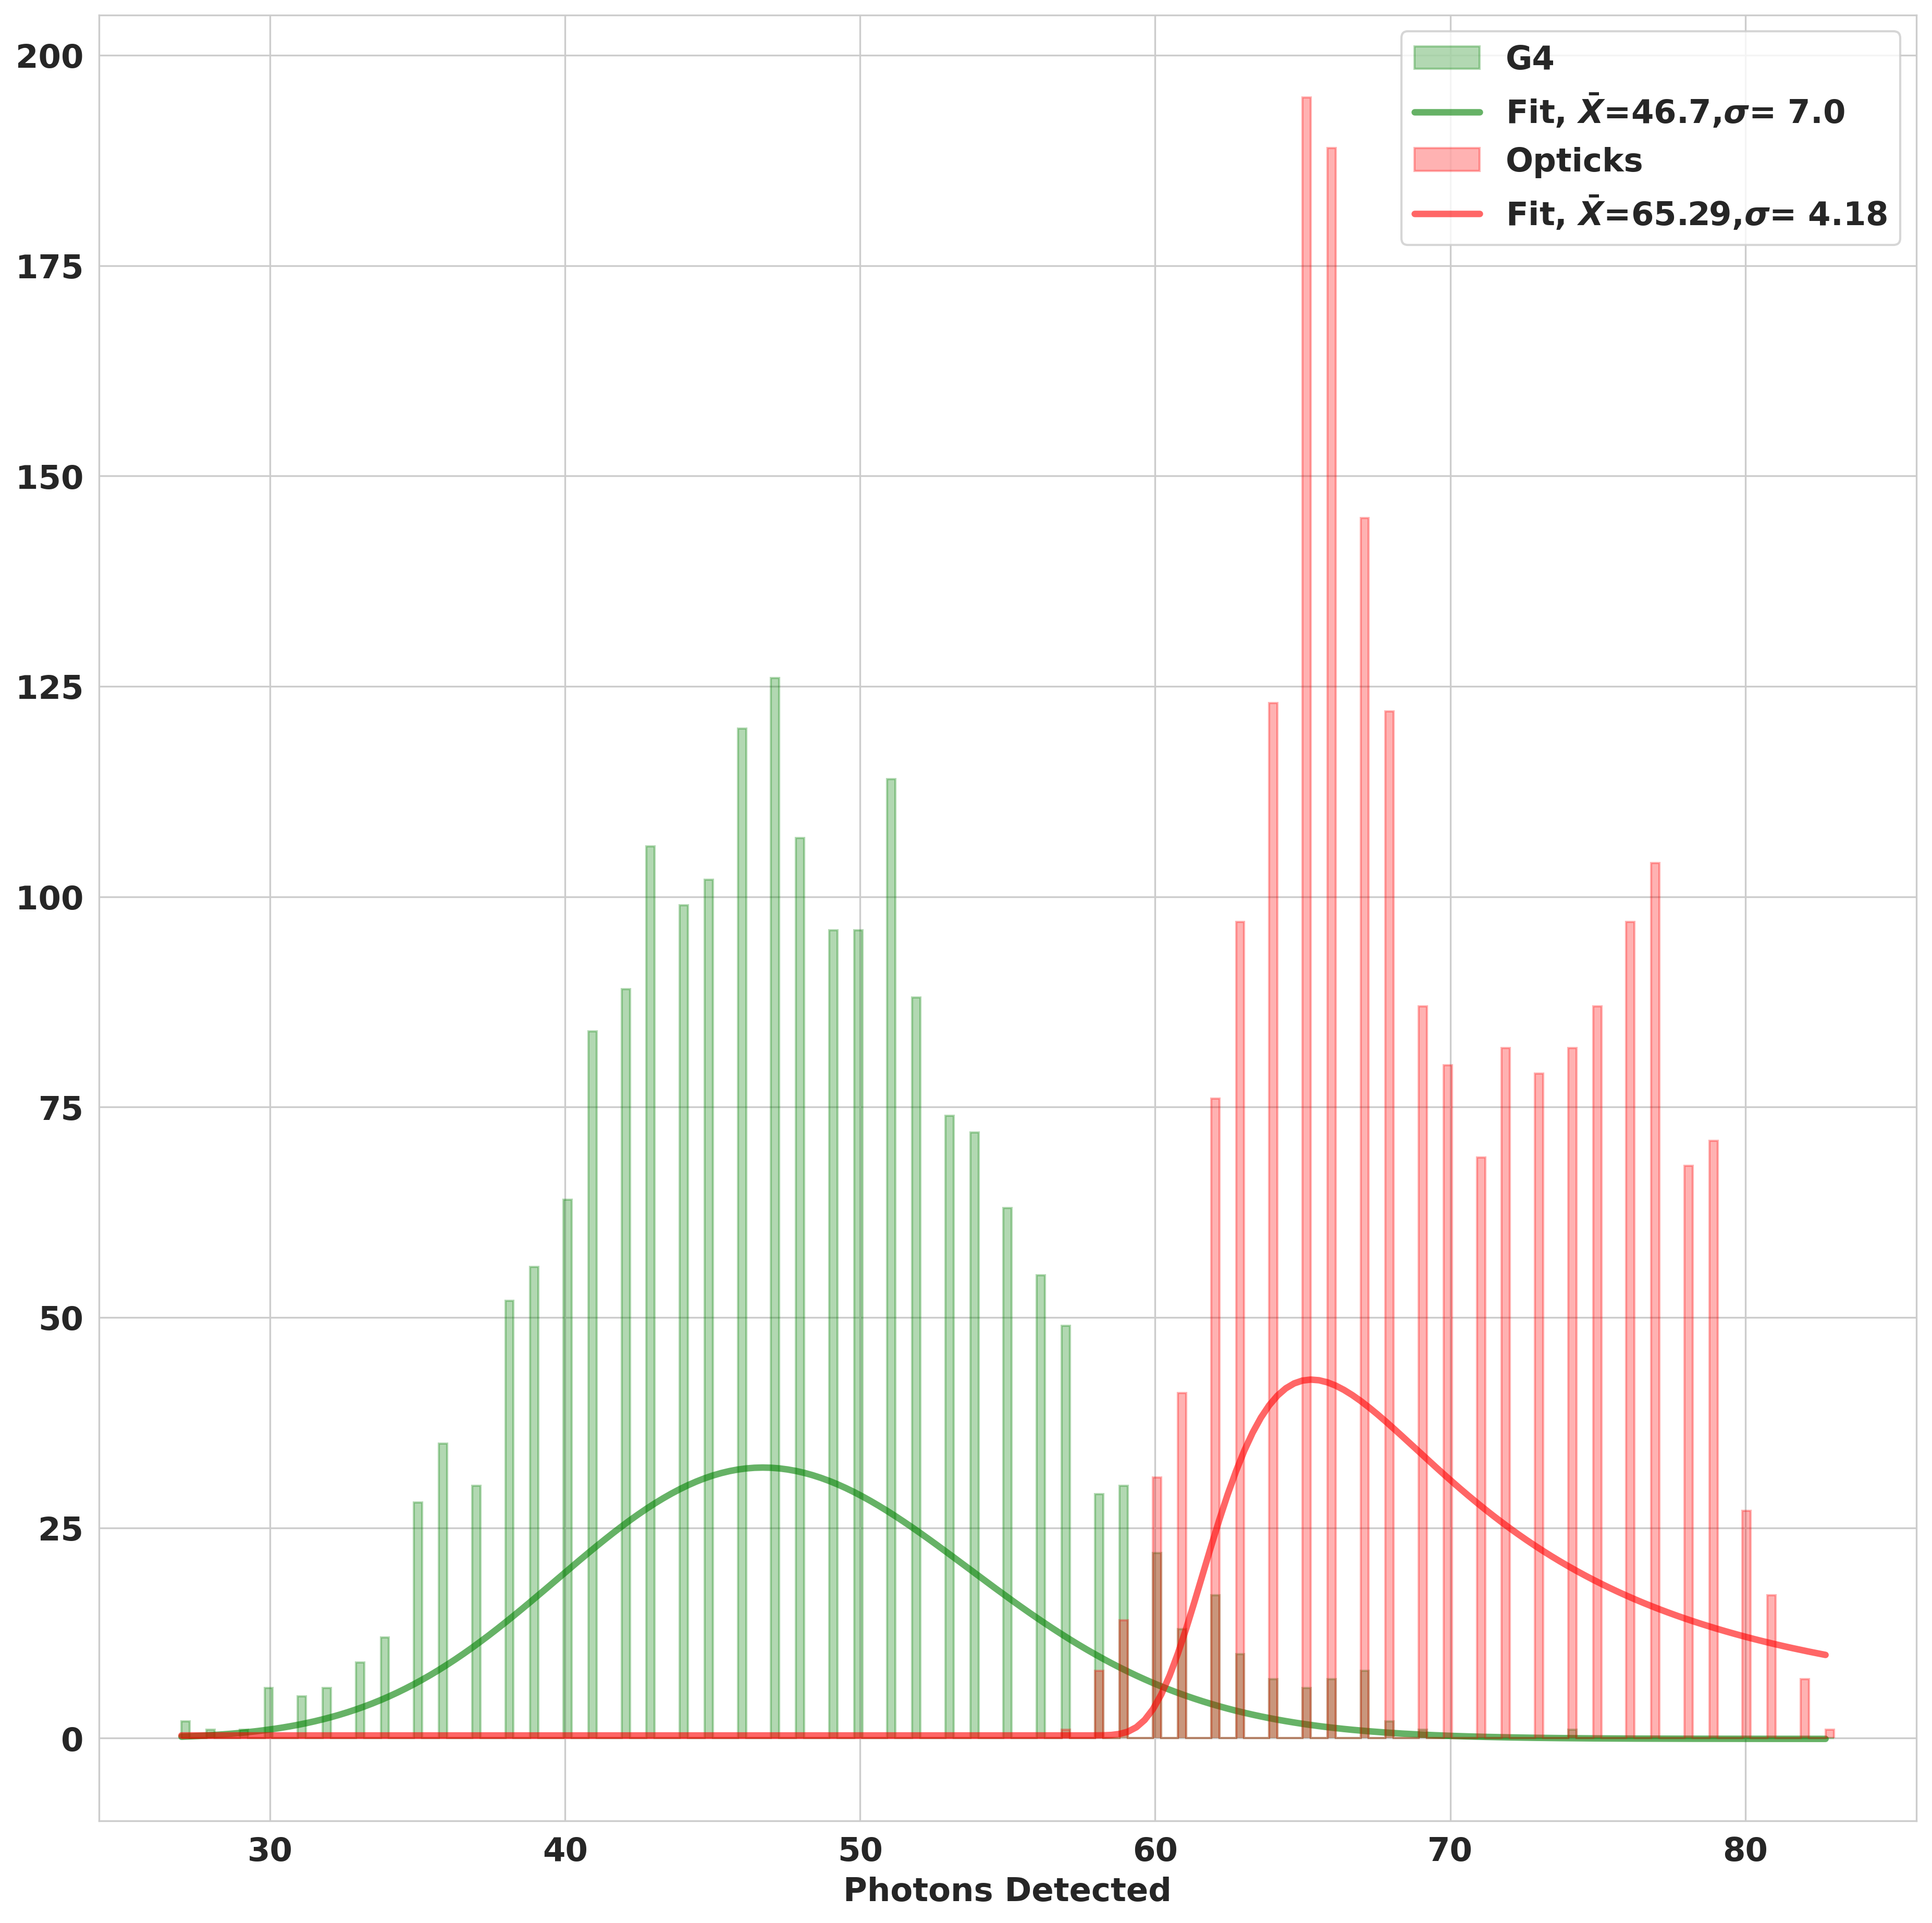

In [80]:

Binsize=200
G4=getHits(G4Hits,Geant4CamMask)
O=getHits(OpticksHits,OpticksCamMask)
maXX=np.max(np.array([np.max(G4),np.max(O)]))
miNX=np.min(np.array([np.min(G4),np.min(O)]))
lins1X=np.linspace(miNX,maXX,Binsize)
plt.figure(figsize=(15,15),dpi=300)
h1=plt.hist(G4,bins=lins1X,label="G4",color="green",alpha=0.3,edgecolor="green",histtype="step",fill=True)
FitHist1D(h1,plt,"Fit","green",0.6)

h2=plt.hist(O,bins=lins1X,label="Opticks",alpha=0.3,color="red",edgecolor="red",histtype="step",fill=True)
FitHist1D(h2,plt,"Fit","red",0.6)

plt.xlabel("Photons Detected")

plt.legend()
del h1,h2

Initials (70.0, 167.8400335008375, 20.616193265525304, 0, 0)
{'Amp': 28.56, 'u': 166.92, 'sigma': 12.88, 'offset': 0.05}
Initials (173.0, 174.1256281407035, 9.526497869173188, 0, 0)
{'Amp': 81.58, 'u': 170.69, 'sigma': 3.95, 'offset': 0.17}


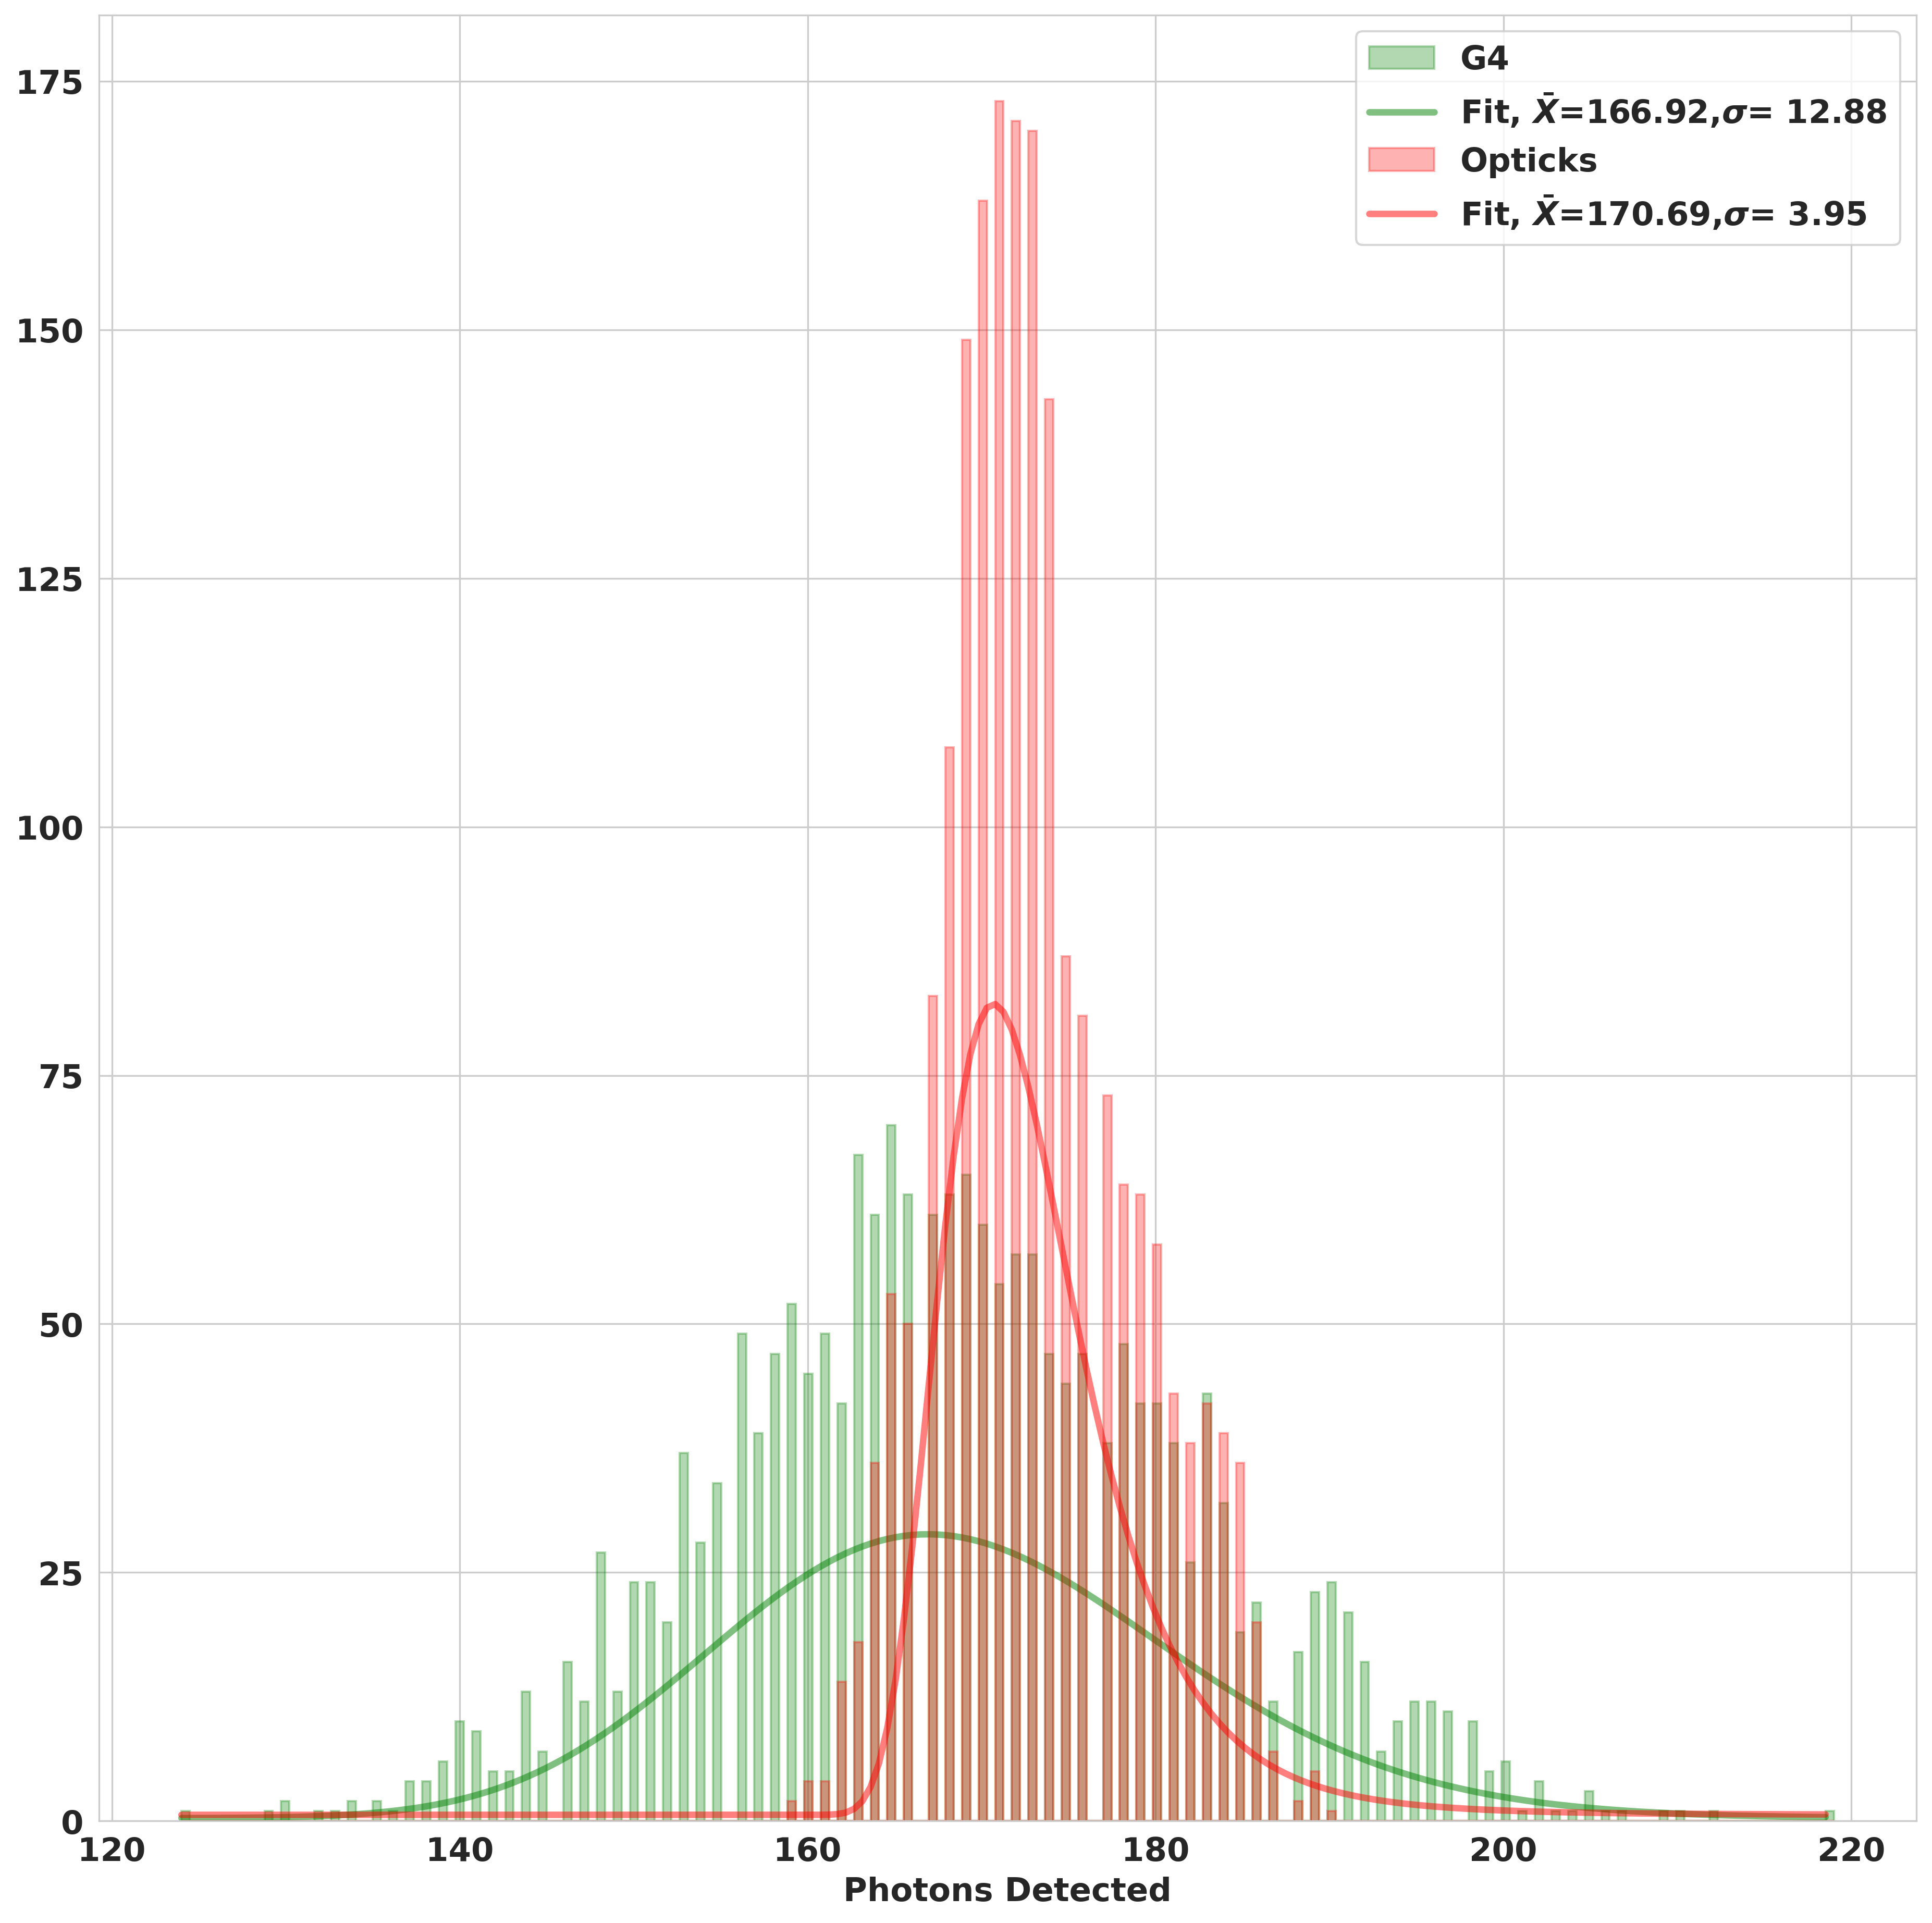

In [81]:
plt.figure(figsize=(15,15),dpi=300)
Binsize=200
G4=getHits(G4Hits,Geant4PMTMask)
O=getHits(OpticksHits,OpticksPMTMask)
maXX=np.max(np.array([np.max(G4),np.max(O)]))
miNX=np.min(np.array([np.min(G4),np.min(O)]))
lins1X=np.linspace(miNX,maXX,Binsize)

h1=plt.hist(G4,bins=lins1X,label="G4",alpha=0.3,color="green",edgecolor="green",histtype="step",fill=True)
FitHist1D(h1,plt,"Fit","green",0.5)

h2=plt.hist(O,bins=lins1X,label="Opticks",alpha=0.3,color="red",edgecolor="red",histtype="step",fill=True)
FitHist1D(h2,plt,"Fit","red",0.5)

plt.xlabel("Photons Detected")
plt.legend()
del h1,h2

In [82]:
#_=plt.hist2d(Opticks["x"],Opticks["z"],bins=500)